<hr style="border: 4px solid #2e7d32;">

**<h1 style="font-size:36px;">🌎🤖 TUGAS WEEK 5 - VISUALISASI DATA PADA DATASET GLOBAL AI ADOPTION & WORKFORCE IMPACT DATASET</h1>**

<hr style="border: 4px solid #2e7d32;">

<table style="font-size:18px; border-collapse: collapse; width: 60%;">
  <tr>
    <td colspan="2" style="font-weight:bold; font-size:22px; background-color:#f2f2f2; padding:8px;">
    👩🏻‍🎓 Identitas Mahasiswa
    </td>
  </tr>
  <tr>
    <td style="font-weight:bold; width: 150px; padding:6px;">Nama</td>
    <td style="padding:6px;">: Anila Dwi Lestari</td>
  </tr>
  <tr>
    <td style="font-weight:bold; padding:6px;">NIM</td>
    <td style="padding:6px;">: 203012520036</td>
  </tr>
</table>

**Link Dataset : [Global AI Adoption Dataset](https://www.kaggle.com/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset)**

Dataset Global AI Adoption & Workforce Impact terdiri dari tiga file CSV utama, yaitu ai_company_adoption.csv, ai_industry_summary.csv, dan country_ai_index.csv. File **ai_company_adoption.csv** merupakan dataset utama yang berisi **150.000 baris dan 43 kolom**, di mana setiap baris merepresentasikan hasil survei tingkat perusahaan yang mencakup perilaku adopsi Artificial Intelligence (AI), dampaknya terhadap tenaga kerja, perubahan operasional, serta aspek tata kelola perusahaan. Dataset ini digunakan untuk menganalisis pola adopsi AI di berbagai industri dan negara, serta memahami faktor-faktor yang memengaruhi tingkat adopsi tersebut dalam skala global.

# **DATA SUDAH BERSIH (JADI TIDAK PERLU DICLEANING)**

<hr style="border: 4px solid #2e7d32;">

**<h1 style="font-size:36px;">1️⃣ EXPLORE DATASET</h1>**

<hr style="border: 4px solid #2e7d32;">

In [ ]:
# ===========================================================================================================================
# IMPORT LIBRARY
# ===========================================================================================================================

import os
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
# ===========================================================================================================================
# IMPORT KAGGLE DATASET
# ===========================================================================================================================

path = kagglehub.dataset_download("mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'global-ai-adoption-and-workforce-impact-dataset' dataset.
Path to dataset files: /kaggle/input/global-ai-adoption-and-workforce-impact-dataset


In [ ]:
# ===========================================================================================================================
# CEK ISI DATASET
# ===========================================================================================================================

path = "/root/.cache/kagglehub/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset/versions/1"
os.listdir(path)

['ai_company_adoption.csv', 'ai_industry_summary.csv', 'country_ai_index.csv']

In [ ]:
# ===========================================================================================================================
# LOAD SEMUA DATASET (3 FILE CSV)
# ===========================================================================================================================

base_path = kagglehub.dataset_download("mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset")

df_company  = pd.read_csv(os.path.join(base_path, 'ai_company_adoption.csv'))
df_industry  = pd.read_csv(os.path.join(base_path, 'ai_industry_summary.csv'))
df_country  = pd.read_csv(os.path.join(base_path, 'country_ai_index.csv'))

print("\nUkuran masing-masing dataset:")
print(f"  df_company  : {df_company.shape[0]:,} baris, {df_company.shape[1]} kolom")
print(f"  df_industry : {df_industry.shape[0]:,} baris, {df_industry.shape[1]} kolom")
print(f"  df_country  : {df_country.shape[0]:,} baris, {df_country.shape[1]} kolom")

Using Colab cache for faster access to the 'global-ai-adoption-and-workforce-impact-dataset' dataset.

Ukuran masing-masing dataset:
  df_company  : 150,000 baris, 43 kolom
  df_industry : 9 baris, 8 kolom
  df_country  : 30 baris, 8 kolom


In [ ]:
# ===========================================================================================================================
# PREVIEW DATASET
# ===========================================================================================================================

print("\n--- PREVIEW: df_company (5 baris pertama) ---")
display(df_company.head())

print("\n--- PREVIEW: df_industry (5 baris pertama) ---")
display(df_industry.head())

print("\n--- PREVIEW: df_country (5 baris pertama) ---")
display(df_country.head())


--- PREVIEW: df_company (5 baris pertama) ---


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation



--- PREVIEW: df_industry (5 baris pertama) ---


,industry,avg_ai_adoption_rate,avg_productivity_change_percent,avg_ai_maturity_score,avg_ai_failure_rate,avg_jobs_displaced,avg_jobs_created,avg_customer_satisfaction
0,Agriculture,35.25,8.80,0.33,26.19,106.09,115.28,5.37
1,Consulting,34.52,8.65,0.33,26.46,106.33,116.06,5.35
2,Education,35.23,8.79,0.33,26.13,111.25,122.58,5.37
3,Finance,38.35,9.50,0.35,25.12,98.44,110.42,5.45
4,Healthcare,34.57,8.60,0.33,26.44,101.51,110.98,5.35



--- PREVIEW: df_country (5 baris pertama) ---


,country,region,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
0,USA,North America,72596.06,92.10,87.14,Moderate,19952,417.69
1,Canada,North America,55834.08,96.78,84.67,Moderate,4233,393.62
2,Germany,Europe,54777.23,91.98,85.01,Strict,6475,369.58
3,UK,Europe,52827.64,91.41,83.85,Moderate,5612,345.98
4,France,Europe,47719.02,92.23,83.46,Moderate,4722,353.71


In [ ]:
# ===========================================================================================================================
# INFORMASI DATASET
# ===========================================================================================================================

for name, df in [("df_company", df_company), ("df_industry", df_industry), ("df_country", df_country)]:
    print(f"\n{'='*60}")
    print(f"INFO DATASET: {name}")
    print(f"{'='*60}")
    print(f"Ukuran Data  : {df.shape}")
    print(f"Jumlah baris : {df.shape[0]:,}")
    print(f"Jumlah kolom : {df.shape[1]}")
    print("\nInfo Kolom:")
    print(df.info())


INFO DATASET: df_company
Ukuran Data  : (150000, 43)
Jumlah baris : 150,000
Jumlah kolom : 43

Info Kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150000 non-null  int64  
 1   company_id                   150000 non-null  object 
 2   survey_year                  150000 non-null  int64  
 3   quarter                      150000 non-null  object 
 4   country                      150000 non-null  object 
 5   region                       150000 non-null  object 
 6   industry                     150000 non-null  object 
 7   company_size                 150000 non-null  object 
 8   num_employees                150000 non-null  int64  
 9   annual_revenue_usd_millions  150000 non-null  float64
 10  company_founding_year        150000 non-null  int64  
 11  company_a

In [ ]:
# ===========================================================================================================================
# STATISTIK DESKRIPTIF
# ===========================================================================================================================

print("\n--- STATISTIK DESKRIPTIF: df_company ---")
display(df_company.describe().T)

print("\n--- STATISTIK DESKRIPTIF: df_industry ---")
display(df_industry.describe().T)

print("\n--- STATISTIK DESKRIPTIF: df_country ---")
display(df_country.describe().T)


--- STATISTIK DESKRIPTIF: df_company ---


,count,mean,std,min,25%,50%,75%,max
response_id,150000.0,79961.106207,46158.813039,1.00,40020.75,79937.500,119913.250,160000.000
survey_year,150000.0,2024.500987,1.118013,2023.00,2024.00,2025.000,2026.000,2026.000
num_employees,150000.0,2342.376580,4754.424755,10.00,69.00,349.000,884.000,19970.000
annual_revenue_usd_millions,150000.0,1180.345751,2391.471420,1.01,33.88,184.160,444.150,9996.730
company_founding_year,150000.0,2005.993767,9.473220,1990.00,1998.00,2006.000,2014.000,2022.000
company_age,150000.0,18.507220,9.539367,1.00,10.00,18.000,27.000,36.000
ai_adoption_rate,150000.0,36.414726,14.544096,0.00,26.43,36.320,46.200,100.000
years_using_ai,150000.0,4.931580,2.429316,0.00,3.00,5.000,7.000,10.000
num_ai_tools_used,150000.0,2.315120,0.946826,1.00,2.00,2.000,3.000,6.000
ai_projects_active,150000.0,6.270693,3.500142,0.00,4.00,6.000,9.000,20.000



--- STATISTIK DESKRIPTIF: df_industry ---


,count,mean,std,min,25%,50%,75%,max
avg_ai_adoption_rate,9.0,36.120000,2.657419,34.52,34.70,35.23,35.26,42.47
avg_productivity_change_percent,9.0,9.186667,0.793048,8.60,8.79,8.99,9.13,11.17
avg_ai_maturity_score,9.0,0.341111,0.026667,0.33,0.33,0.33,0.33,0.41
avg_ai_failure_rate,9.0,25.881111,0.963113,23.56,26.13,26.27,26.38,26.46
avg_jobs_displaced,9.0,111.031111,10.271640,98.44,106.09,111.25,114.99,133.74
avg_jobs_created,9.0,117.026667,12.814132,107.65,110.42,111.10,116.06,149.08
avg_customer_satisfaction,9.0,5.412222,0.090661,5.35,5.37,5.39,5.40,5.64



--- STATISTIK DESKRIPTIF: df_country ---


,count,mean,std,min,25%,50%,75%,max
gdp_per_capita,30.0,32440.890667,22661.367334,5618.81,12328.0050,23866.050,54194.3875,72930.10
internet_penetration,30.0,83.219333,11.539216,56.40,75.5825,86.495,92.1975,96.78
digital_maturity_index,30.0,77.157000,9.982764,59.10,69.7150,76.155,86.7975,92.82
ai_patent_filings_2024,30.0,3441.233333,4551.596550,191.00,981.2500,2020.500,3992.2500,19952.00
ai_researchers_per_million,30.0,255.292667,138.619315,55.23,124.9700,261.135,379.0600,501.20


In [ ]:
df_clean = df_company.copy()

TARGET = 'ai_adoption_rate'
assert TARGET in df_clean.columns, f'Kolom target tidak ditemukan! Kolom tersedia: {list(df_clean.columns)}'
print(f'Target Variabel : {TARGET}')
print(f'Rentang Nilai   : {df_clean[TARGET].min():.1f}% - {df_clean[TARGET].max():.1f}%')
print(f'Rata-rata       : {df_clean[TARGET].mean():.2f}%')
print(f'Median          : {df_clean[TARGET].median():.2f}%')

CLR_PRIMARY   = '#6a0dad'
CLR_SECONDARY = '#9b59b6'
CLR_SOFT      = '#c39bd3'
CLR_DARK      = '#4a235a'
CLR_GRADIENT  = lambda n: plt.cm.Purples(np.linspace(0.3, 0.92, n))
HEATMAP_CMAP  = 'BuPu'

Target Variabel : ai_adoption_rate
Rentang Nilai   : 0.0% - 100.0%
Rata-rata       : 36.41%
Median          : 36.32%


In [ ]:
# ===========================================================================================================================
# DATA DICTIONARY
# ===========================================================================================================================

import pandas as pd

data_dict = [
    ['survey_year', 'int64', 'Tahun survei dilakukan (2020-2024)', 'General'],
    ['quarter', 'categorical (OHE)', 'Kuartal survei (Q1-Q4)', 'General'],
    ['country', 'categorical', 'Negara perusahaan', 'General'],
    ['region', 'categorical', 'Wilayah geografis perusahaan', 'General'],
    ['industry', 'categorical (OHE)', 'Sektor industri perusahaan', 'General'],

    ['company_size', 'ordinal (0-2)', 'Ukuran perusahaan (Startup < SME < Enterprise)', 'Company'],
    ['num_employees', 'int64', 'Jumlah karyawan', 'Company'],
    ['annual_revenue_usd_millions', 'float64', 'Pendapatan tahunan (juta USD)', 'Company'],
    ['company_founding_year', 'int64', 'Tahun didirikan', 'Company'],
    ['company_age', 'int64', 'Usia perusahaan (tahun)', 'Company'],
    ['company_age_group', 'ordinal (0-3)', 'Kelompok usia perusahaan', 'Company'],

    ['ai_adoption_rate', 'float64', 'TARGET: Tingkat adopsi AI (%)', 'AI Adoption'],
    ['ai_adoption_stage', 'ordinal (0-3)', 'Tahapan adopsi AI (none → full)', 'AI Adoption'],
    ['years_using_ai', 'int64', 'Lama penggunaan AI (tahun)', 'AI Adoption'],
    ['ai_primary_tool', 'categorical (OHE)', 'Tools AI utama', 'AI Adoption'],
    ['num_ai_tools_used', 'int64', 'Jumlah tools AI', 'AI Adoption'],
    ['ai_use_case', 'categorical (OHE)', 'Use case AI utama', 'AI Adoption'],
    ['ai_projects_active', 'int64', 'Jumlah proyek AI aktif', 'AI Adoption'],
    ['ai_training_hours', 'float64', 'Jam pelatihan AI per tahun', 'AI Adoption'],

    ['ai_budget_percentage', 'float64', 'Persentase budget untuk AI', 'Investment'],
    ['ai_maturity_score', 'float64', 'Skor kematangan AI (0-100)', 'Investment'],
    ['ai_failure_rate', 'float64', 'Tingkat kegagalan proyek AI (%)', 'Investment'],
    ['ai_investment_per_employee', 'float64', 'Investasi AI per karyawan (USD)', 'Investment'],

    ['regulatory_compliance_score', 'int64', 'Skor kepatuhan regulasi', 'Governance'],
    ['data_privacy_level', 'ordinal (0-2)', 'Tingkat privasi data', 'Governance'],
    ['ai_ethics_committee', 'categorical (OHE)', 'Ada/tidaknya komite etika AI', 'Governance'],
    ['ai_risk_management_score', 'int64', 'Skor manajemen risiko AI', 'Governance'],

    ['remote_work_percentage', 'float64', 'Persentase remote work', 'Workforce'],
    ['employee_satisfaction_score', 'float64', 'Kepuasan karyawan (0-10)', 'Workforce'],
    ['task_automation_rate', 'float64', 'Tingkat otomatisasi (%)', 'Workforce'],
    ['time_saved_per_week', 'float64', 'Waktu hemat per minggu (jam)', 'Workforce'],

    ['productivity_change_percent', 'float64', 'Perubahan produktivitas (%)', 'Business'],
    ['jobs_displaced', 'int64', 'Jumlah pekerjaan tergantikan', 'Business'],
    ['jobs_created', 'int64', 'Jumlah pekerjaan baru', 'Business'],
    ['reskilled_employees', 'int64', 'Jumlah karyawan di-reskill', 'Business'],
    ['revenue_growth_percent', 'float64', 'Pertumbuhan pendapatan (%)', 'Business'],
    ['cost_reduction_percent', 'float64', 'Pengurangan biaya (%)', 'Business'],
    ['innovation_score', 'int64', 'Skor inovasi (0-100)', 'Business'],
    ['customer_satisfaction', 'float64', 'Kepuasan pelanggan (0-10)', 'Business'],
]

dict_df = pd.DataFrame(data_dict, columns=['Kolom', 'Tipe', 'Deskripsi', 'Kategori'])
dict_df.insert(0, 'No', range(1, len(dict_df) + 1))

# ===========================================================================================================================
# COLOR MAP (BACKGROUND)
# ===========================================================================================================================

def highlight_category(val):
    color_map = {
        'General': '#F3E5F5',
        'Company': '#EDE7F6',
        'AI Adoption': '#E1BEE7',
        'Investment': '#CE93D8',
        'Governance': '#BA68C8',
        'Workforce': '#AB47BC',
        'Business': '#9C27B0'
    }
    return f'background-color: {color_map.get(val, "black")}'

# kategori yang teksnya dibuat hitam
target_kategori = ['General', 'Company', 'AI Adoption']

def text_black(val):
    if val in target_kategori:
        return 'color: black'
    return ''

# ===========================================================================================================================
# STYLING
# ===========================================================================================================================

styled_df = dict_df.style \
    .map(highlight_category, subset=['Kategori']) \
    .map(text_black, subset=['Kategori']) \
    .set_properties(**{
        'text-align': 'left'
    }) \
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#6A1B9A'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('padding', '8px')
            ]
        }
    ]) \
    .hide(axis="index")

display(styled_df)

No,Kolom,Tipe,Deskripsi,Kategori
1,survey_year,int64,Tahun survei dilakukan (2020-2024),General
2,quarter,categorical (OHE),Kuartal survei (Q1-Q4),General
3,country,categorical,Negara perusahaan,General
4,region,categorical,Wilayah geografis perusahaan,General
5,industry,categorical (OHE),Sektor industri perusahaan,General
6,company_size,ordinal (0-2),Ukuran perusahaan (Startup < SME < Enterprise),Company
7,num_employees,int64,Jumlah karyawan,Company
8,annual_revenue_usd_millions,float64,Pendapatan tahunan (juta USD),Company
9,company_founding_year,int64,Tahun didirikan,Company
10,company_age,int64,Usia perusahaan (tahun),Company


<hr style="border: 4px solid #2e7d32;">

**<h1 style="font-size:36px;">2️⃣ VISUALISASI DATA</h1>**

<hr style="border: 4px solid #2e7d32;">

# **DASHBOARD INTERAKTIF**

In [ ]:
# Install ydata-profiling if not already installed
!pip install ydata-profiling -qq

In [ ]:
!pip install ydata-profiling -qq

import pandas as pd
from ydata_profiling import ProfileReport

profile_company = ProfileReport(
    df_company,
    title       = "AI Company Adoption - Profiling Report",
    minimal     = True,
    progress_bar= True,
)
profile_company.to_file("report_company.html")
profile_company.to_notebook_iframe()

profile_industry = ProfileReport(
    df_industry,
    title       = "AI Industry Summary - Profiling Report",
    minimal     = False,
    progress_bar= True,
)
profile_industry.to_file("report_industry.html")
profile_industry.to_notebook_iframe()

profile_country = ProfileReport(
    df_country,
    title       = "Country AI Index - Profiling Report",
    minimal     = False,
    progress_bar= True,
)
profile_country.to_file("report_country.html")
profile_country.to_notebook_iframe()

In [ ]:
import pandas as pd
from ydata_profiling import ProfileReport

df_report = df_clean  # Using df_clean as the main DataFrame for the report
profile = ProfileReport(df_report, title="Profiling Report")
display(profile)

# **VISUALISASI LAINNYA**

In [ ]:
# ===========================================================================================================================
# DISTRIBUSI FITUR NUMERIK - INTERAKTIF DENGAN DROPDOWN (df_company)
# ===========================================================================================================================

import plotly.graph_objects as go
import numpy as np

num_cols = [
    'ai_adoption_rate', 'ai_maturity_score', 'ai_failure_rate', 'ai_budget_percentage',
    'ai_investment_per_employee', 'ai_training_hours', 'num_ai_tools_used',
    'ai_projects_active', 'years_using_ai', 'num_employees', 'annual_revenue_usd_millions',
    'company_age', 'regulatory_compliance_score', 'ai_risk_management_score',
    'remote_work_percentage', 'employee_satisfaction_score', 'task_automation_rate',
    'time_saved_per_week', 'productivity_change_percent', 'jobs_displaced',
    'jobs_created', 'reskilled_employees', 'revenue_growth_percent',
    'cost_reduction_percent', 'innovation_score', 'customer_satisfaction'
]

CLR_BAR    = '#6a0dad'
CLR_MEAN   = '#3b0764'
CLR_MEDIAN = '#7c3aed'

fig = go.Figure()

for i, col in enumerate(num_cols):
    values     = df_clean[col].dropna()
    mean_val   = values.mean()
    median_val = values.median()
    visible    = (i == 0)

    fig.add_trace(go.Histogram(
        x=values,
        nbinsx=40,
        name=col,
        marker=dict(color=CLR_BAR, line=dict(color='white', width=0.3)),
        opacity=0.9,
        visible=visible,
        showlegend=False,
        hovertemplate=f'<b>{col}</b><br>Range: %{{x}}<br>Count: %{{y}}<extra></extra>'
    ))

    fig.add_trace(go.Scatter(
        x=[mean_val, mean_val],
        y=[0, 1],
        mode='lines',
        line=dict(color=CLR_MEAN, dash='dash', width=2.5),
        name=f'mean = {mean_val:.2f}',
        visible=visible,
        yaxis='y2',
        hovertemplate=f'mean = {mean_val:.2f}<extra></extra>'
    ))

    fig.add_trace(go.Scatter(
        x=[median_val, median_val],
        y=[0, 1],
        mode='lines',
        line=dict(color=CLR_MEDIAN, dash='dot', width=2.5),
        name=f'median = {median_val:.2f}',
        visible=visible,
        yaxis='y2',
        hovertemplate=f'median = {median_val:.2f}<extra></extra>'
    ))

buttons = []
n_traces = 3

for i, col in enumerate(num_cols):
    values     = df_clean[col].dropna()
    mean_val   = values.mean()
    median_val = values.median()

    visible_arr = [False] * (len(num_cols) * n_traces)
    visible_arr[i * n_traces]     = True
    visible_arr[i * n_traces + 1] = True
    visible_arr[i * n_traces + 2] = True

    buttons.append(dict(
        label=col,
        method='update',
        args=[
            {'visible': visible_arr},
            {
                'title': f'Distribution of <b>{col}</b>',
                'xaxis': {'title': col, 'showgrid': True, 'gridcolor': 'rgba(0,0,0,0.06)'},
                'annotations': [
                    dict(
                        text='<b>Select Feature :</b>',
                        x=0.01, y=1.21, xref='paper', yref='paper',
                        showarrow=False, font=dict(size=12, color=CLR_MEAN)
                    ),
                    dict(
                        x=mean_val, y=0.97, xref='x', yref='paper',
                        text=f'mean = {mean_val:.2f}',
                        showarrow=True, arrowhead=2, arrowcolor=CLR_MEAN,
                        font=dict(color=CLR_MEAN, size=11),
                        bgcolor='white', bordercolor=CLR_MEAN, borderwidth=1
                    ),
                    dict(
                        x=median_val, y=0.83, xref='x', yref='paper',
                        text=f'median = {median_val:.2f}',
                        showarrow=True, arrowhead=2, arrowcolor=CLR_MEDIAN,
                        font=dict(color=CLR_MEDIAN, size=11),
                        bgcolor='white', bordercolor=CLR_MEDIAN, borderwidth=1
                    ),
                ]
            }
        ]
    ))

init_col    = num_cols[0]
init_mean   = df_clean[init_col].mean()
init_median = df_clean[init_col].median()

fig.update_layout(
    title=dict(
        text=f'Distribution of <b>{init_col}</b>',
        font=dict(size=18, color=CLR_MEAN),
        x=0.5
    ),
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.01,
        xanchor='left',
        y=1.15,
        yanchor='top',
        bgcolor='#ede7f6',
        bordercolor=CLR_BAR,
        font=dict(size=11, color=CLR_MEAN)
    )],
    annotations=[
        dict(
            text='<b>Select Feature :</b>',
            x=0.01, y=1.21, xref='paper', yref='paper',
            showarrow=False, font=dict(size=12, color=CLR_MEAN)
        ),
        dict(
            x=init_mean, y=0.97, xref='x', yref='paper',
            text=f'mean = {init_mean:.2f}',
            showarrow=True, arrowhead=2, arrowcolor=CLR_MEAN,
            font=dict(color=CLR_MEAN, size=11),
            bgcolor='white', bordercolor=CLR_MEAN, borderwidth=1
        ),
        dict(
            x=init_median, y=0.83, xref='x', yref='paper',
            text=f'median = {init_median:.2f}',
            showarrow=True, arrowhead=2, arrowcolor=CLR_MEDIAN,
            font=dict(color=CLR_MEDIAN, size=11),
            bgcolor='white', bordercolor=CLR_MEDIAN, borderwidth=1
        ),
    ],
    xaxis=dict(title=init_col, showgrid=True, gridcolor='rgba(0,0,0,0.06)'),
    yaxis=dict(title='frequency', showgrid=True, gridcolor='rgba(0,0,0,0.06)'),
    yaxis2=dict(overlaying='y', range=[0, 1], showticklabels=False),
    paper_bgcolor='#faf5ff',
    plot_bgcolor='white',
    height=550,
    width=950,
    bargap=0.05,
    margin=dict(t=120, b=60, l=60, r=40),
    legend=dict(
        x=0.82, y=0.97,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor=CLR_BAR,
        borderwidth=1
    )
)

fig.write_html('distribution_dropdown.html')
fig.show()

## **Insight Distribusi Fitur Numerikal (df_company)**

Berdasarkan histogram fitur numerikal di atas, sebagian besar data memiliki distribusi yang mendekati normal, sehingga menunjukkan penyebaran data yang cukup stabil dan tidak terlalu ekstrem. Nilai seperti **ai_adoption_rate**, **employee_satisfaction_score**, **customer_satisfaction**, dan **remote_work_percentage** cenderung terpusat di nilai tengah, artinya mayoritas perusahaan memiliki tingkat adopsi AI, kepuasan karyawan, dan kepuasan pelanggan pada level sedang hingga tinggi.

Pada fitur **ai_budget_percentage** dan **training_hours**, terlihat bahwa perusahaan rata-rata mengalokasikan budget AI dalam jumlah moderat dan cukup aktif memberikan pelatihan AI kepada karyawan. Selain itu, **task_automation_rate** dan **time_saved_per_week** menunjukkan bahwa implementasi AI cukup membantu otomatisasi pekerjaan dan efisiensi waktu kerja.

Beberapa fitur seperti **ai_investment_per_employee**, **annual_revenue_usd_millions**, **jobs_created**, dan **jobs_displaced** memiliki distribusi yang miring ke kanan (*right skewed*), yang berarti hanya sebagian kecil perusahaan yang memiliki nilai sangat tinggi dibanding mayoritas lainnya. Hal ini menunjukkan adanya gap besar antar perusahaan dalam investasi AI maupun dampaknya terhadap tenaga kerja.

Dari sisi performa bisnis, fitur **productivity_change_percent**, **revenue_growth_percent**, dan **cost_reduction_percent** menunjukkan tren positif setelah penerapan AI. Selain itu, nilai **innovation_score** dan **regulatory_compliance_score** yang cukup tinggi mengindikasikan bahwa banyak perusahaan mulai fokus pada inovasi sekaligus kepatuhan regulasi dalam penggunaan AI.

In [ ]:
# ===========================================================================================================================
# DISTRIBUSI SEMUA FITUR KATEGORIKAL (df_company)
# ===========================================================================================================================

import plotly.graph_objects as go

cat_cols = [
    'survey_year', 'quarter', 'region', 'industry', 'company_size',
    'company_age_group', 'ai_adoption_stage', 'ai_primary_tool',
    'ai_use_case', 'data_privacy_level', 'ai_ethics_committee',
    'survey_source', 'data_collection_method'
]

CLR_BAR  = '#6a0dad'
CLR_DARK = '#3b0764'
CLR_BG   = '#faf5ff'

def get_purple_shades(n):
    base = ['#3b0764', '#4c0b8a', '#6a0dad', '#7c3aed', '#8b5cf6', '#a78bfa', '#c4b5fd']
    return (base * math.ceil(n / len(base)))[:n]

fig = go.Figure()

for i, col in enumerate(cat_cols):
    counts  = df_clean[col].value_counts().sort_values()
    labels  = counts.index.tolist()
    values  = counts.values.tolist()
    colors  = get_purple_shades(len(labels))
    visible = (i == 0)

    fig.add_trace(go.Bar(
        x=values,
        y=labels,
        orientation='h',
        marker=dict(color=colors, line=dict(color='white', width=0.5)),
        text=[f'{v:,}' for v in values],
        textposition='outside',
        textfont=dict(size=10, color=CLR_DARK),
        hovertemplate='<b>%{y}</b><br>count: %{x:,}<extra></extra>',
        visible=visible,
        showlegend=False,
        name=col
    ))

buttons = []

for i, col in enumerate(cat_cols):
    counts = df_clean[col].value_counts().sort_values()
    labels = counts.index.tolist()

    visible_arr = [False] * len(cat_cols)
    visible_arr[i] = True

    buttons.append(dict(
        label=col,
        method='update',
        args=[
            {'visible': visible_arr},
            {
                'xaxis': {'title': 'count', 'showgrid': True, 'gridcolor': 'rgba(0,0,0,0.06)'},
                'yaxis': {'title': col, 'autorange': True, 'domain': [0, 0.75]},
            }
        ]
    ))

init_col    = cat_cols[0]
init_counts = df_clean[init_col].value_counts().sort_values()

fig.update_layout(
    annotations=[
        dict(
            text=f'Distribution of <b>{init_col}</b>',
            x=0.5, y=0.97,
            xref='paper', yref='paper',
            showarrow=False,
            font=dict(size=20, color=CLR_DARK),
            xanchor='center'
        ),
        dict(
            text='<b>Select Feature :</b>',
            x=0.01, y=0.87,
            xref='paper', yref='paper',
            showarrow=False,
            font=dict(size=12, color=CLR_DARK),
            xanchor='left'
        )
    ],
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.01,
        xanchor='left',
        y=0.83,
        yanchor='top',
        bgcolor='#ede7f6',
        bordercolor=CLR_BAR,
        borderwidth=1,
        font=dict(size=11, color=CLR_DARK)
    )],
    xaxis=dict(title='count', showgrid=True, gridcolor='rgba(0,0,0,0.06)'),
    yaxis=dict(title=init_col, autorange=True, domain=[0, 0.75]),
    paper_bgcolor=CLR_BG,
    plot_bgcolor='white',
    height=max(550, len(init_counts) * 45 + 300),
    width=950,
    margin=dict(t=30, b=60, l=180, r=120),
    bargap=0.25
)

fig.write_html('distribution_categorical_dropdown.html')
fig.show()

## **Insight Distribusi Fitur Kategorikal (df_company)**

Berdasarkan visualisasi distribusi fitur kategorikal di atas, sebagian besar data memiliki penyebaran kategori yang cukup seimbang pada beberapa variabel seperti **survey_year**, **quarter**, **survey_source**, dan **data_collection_method**. Hal ini menunjukkan bahwa dataset dikumpulkan secara merata dari berbagai periode dan sumber sehingga analisis menjadi lebih representatif.

Pada fitur **region**, perusahaan dari kawasan **Asia** mendominasi dataset, disusul oleh Europe. Sementara itu, industri yang paling banyak muncul adalah **Technology**, kemudian Finance dan Healthcare. Hal ini menunjukkan bahwa adopsi AI paling banyak terjadi pada sektor berbasis teknologi dan pengolahan data.

Dari sisi karakteristik perusahaan, kategori **SME** dan **Startup** memiliki jumlah paling besar dibanding Enterprise. Selain itu, perusahaan dengan usia **16-30 tahun** mendominasi data, yang menandakan bahwa perusahaan yang lebih matang cenderung lebih siap dalam mengimplementasikan AI.

Pada fitur **ai_adoption_stage**, mayoritas perusahaan masih berada pada tahap **partial** dan **pilot**, sehingga implementasi AI secara penuh masih belum banyak dilakukan. Sementara itu, **ChatGPT** menjadi tools AI yang paling sering digunakan dibanding tools lain seperti Claude dan Gemini, menandakan tingginya popularitas generative AI dalam dunia bisnis.

Dari sisi penggunaan AI, fitur **ai_use_case** menunjukkan bahwa AI paling banyak dimanfaatkan untuk **Customer Support**, **HR Automation**, dan **Marketing Automation**. Hal ini menunjukkan bahwa AI lebih banyak digunakan untuk meningkatkan efisiensi operasional dan otomatisasi pekerjaan administratif.

Selain itu, sebagian besar perusahaan memiliki tingkat **data_privacy_level** pada kategori medium hingga high, yang menunjukkan bahwa keamanan data menjadi perhatian penting dalam implementasi AI. Namun, pada fitur **ai_ethics_committee**, mayoritas perusahaan belum memiliki komite etika AI, sehingga tata kelola dan regulasi AI masih menjadi tantangan bagi banyak perusahaan.

In [ ]:
# ===========================================================================================================================
# HEATMAP KORELASI ANTAR VARIABEL NUMERIK (df_company)
# ===========================================================================================================================

import plotly.graph_objects as go
import numpy as np

num_cols = [
    'ai_adoption_rate', 'ai_maturity_score', 'ai_failure_rate', 'ai_budget_percentage',
    'ai_investment_per_employee', 'ai_training_hours', 'num_ai_tools_used',
    'ai_projects_active', 'years_using_ai', 'num_employees', 'annual_revenue_usd_millions',
    'company_age', 'regulatory_compliance_score', 'ai_risk_management_score',
    'remote_work_percentage', 'employee_satisfaction_score', 'task_automation_rate',
    'time_saved_per_week', 'productivity_change_percent', 'jobs_displaced',
    'jobs_created', 'reskilled_employees', 'revenue_growth_percent',
    'cost_reduction_percent', 'innovation_score', 'customer_satisfaction'
]

corr_matrix = df_clean[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_masked = corr_matrix.copy()
corr_masked[mask] = None

text_annot = corr_masked.round(2).astype(str).replace('nan', '')

fig = go.Figure(go.Heatmap(
    z=corr_masked.values,
    x=num_cols,
    y=num_cols,
    text=text_annot.values,
    texttemplate='%{text}',
    textfont=dict(size=8, color='#2d0050'),
    colorscale=[
        [0.0,  '#3b0764'],
        [0.25, '#6a0dad'],
        [0.5,  '#f3e8ff'],
        [0.75, '#c4b5fd'],
        [1.0,  '#7c3aed'],
    ],
    zmid=0,
    zmin=-1,
    zmax=1,
    colorbar=dict(
        title=dict(
            text='Pearson Correlation<br>Coefficient',
            font=dict(size=11, color='#3b0764'),
            side='right'
        ),
        tickfont=dict(size=10, color='#3b0764'),
        thickness=15,
        len=0.8
    ),
    xgap=2,
    ygap=2,
    hovertemplate='<b>%{x}</b> × <b>%{y}</b><br>r = %{z:.4f}<extra></extra>'
))

fig.update_layout(
    title=dict(
        text='Correlation Heatmap of Numerical Features (df_company)',
        font=dict(size=18, color='#3b0764'),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
        tickangle=45,
        tickfont=dict(size=9, color='#3b0764'),
        showgrid=False,
        side='bottom'
    ),
    yaxis=dict(
        tickfont=dict(size=9, color='#3b0764'),
        showgrid=False,
        autorange='reversed'
    ),
    paper_bgcolor='#faf5ff',
    plot_bgcolor='#faf5ff',
    height=850,
    width=1000,
    margin=dict(t=80, b=160, l=160, r=80)
)

fig.write_html('heatmap_correlation_interactive.html')
fig.show()

## **Analisis Heatmap Korelasi**

Analisis ini bertujuan untuk melihat hubungan antarvariabel yang berkaitan dengan implementasi AI serta mengidentifikasi faktor-faktor yang memiliki keterkaitan paling kuat terhadap performa perusahaan. Melalui *heatmap* korelasi, pola hubungan positif maupun negatif antar variabel dapat diamati secara lebih jelas.

Berdasarkan *heatmap* korelasi, terlihat bahwa sebagian besar variabel terkait AI memiliki hubungan positif satu sama lain. Variabel seperti `ai_adoption_rate`, `ai_maturity_score`, dan `ai_training_hours` menunjukkan korelasi cukup tinggi terhadap `productivity_change_percent` dan `task_automation_rate`. Hal ini menandakan bahwa semakin tinggi tingkat adopsi dan kematangan AI dalam perusahaan, maka peningkatan produktivitas dan otomatisasi tugas juga cenderung meningkat.

Selain itu, variabel `ai_failure_rate` memiliki korelasi negatif terhadap beberapa variabel utama, seperti `ai_training_hours` dan `productivity_change_percent`. Ini menunjukkan bahwa semakin tinggi tingkat kegagalan AI, maka dampak positif terhadap produktivitas menjadi lebih rendah. Korelasi kuat juga terlihat antara `jobs_created` dan `reskilled_employees`, yang mengindikasikan bahwa implementasi AI mendorong kebutuhan pelatihan ulang karyawan serta penciptaan pekerjaan baru.

Secara keseluruhan, *heatmap* menunjukkan bahwa investasi, pelatihan, dan penggunaan AI yang lebih matang dapat memberikan dampak positif terhadap efisiensi perusahaan, inovasi, hingga kepuasan pelanggan.

In [ ]:
# ===========================================================================================================================
# SCATTER PLOT HUBUNGAN ANTAR VARIABEL (df_company)
# ===========================================================================================================================

import math
import numpy as np
import plotly.graph_objects as go

scatter_pairs = [
    ('ai_budget_percentage',        'ai_maturity_score',         'ai_adoption_stage'),
    ('ai_training_hours',           'task_automation_rate',      'company_size'),
    ('productivity_change_percent', 'revenue_growth_percent',    'industry'),
    ('task_automation_rate',        'time_saved_per_week',       'ai_adoption_stage'),
    ('innovation_score',            'customer_satisfaction',     'company_size'),
    ('years_using_ai',              'ai_adoption_rate',          'ai_adoption_stage'),
]

PURPLE_SHADES = ['#2e1065', '#4c1d95', '#6d28d9', '#7c3aed', '#8b5cf6', '#a78bfa', '#c4b5fd']
CLR_DARK      = '#3b0764'
CLR_MID       = '#6d28d9'
CLR_BG        = '#faf5ff'
CLR_GRID      = 'rgba(109,40,217,0.08)'
CLR_TREND     = '#4c1d95'


def get_purple_shades(n):
    return (PURPLE_SHADES * math.ceil(n / len(PURPLE_SHADES)))[:n]


sample = df_company.sample(n=min(2000, len(df_company)), random_state=42)

all_traces = []
trace_map  = {}
trace_idx  = 0

for pair_idx, (x_col, y_col, hue_col) in enumerate(scatter_pairs):
    categories  = sorted(sample[hue_col].dropna().unique())
    colors      = get_purple_shades(len(categories))
    pair_traces = []

    for cat, color in zip(categories, colors):
        subset = sample[sample[hue_col] == cat]
        all_traces.append(go.Scatter(
            x=subset[x_col],
            y=subset[y_col],
            mode='markers',
            name=str(cat),
            legendgroup=str(cat),
            legendgrouptitle=dict(text=hue_col.replace('_', ' ')) if cat == categories[0] else None,
            marker=dict(color=color, size=6, opacity=0.65, line=dict(color='white', width=0.4)),
            hovertemplate=(
                f'<b>{hue_col}:</b> {cat}<br>'
                f'<b>{x_col}:</b> %{{x:.2f}}<br>'
                f'<b>{y_col}:</b> %{{y:.2f}}<extra></extra>'
            ),
            visible=(pair_idx == 0),
        ))
        pair_traces.append(trace_idx)
        trace_idx += 1

    x_vals = sample[x_col].values.astype(float)
    y_vals = sample[y_col].values.astype(float)
    mask   = ~(np.isnan(x_vals) | np.isnan(y_vals))
    m, b   = np.polyfit(x_vals[mask], y_vals[mask], 1)
    x_line = np.linspace(x_vals[mask].min(), x_vals[mask].max(), 200)
    corr   = float(np.corrcoef(x_vals[mask], y_vals[mask])[0, 1])

    all_traces.append(go.Scatter(
        x=x_line,
        y=m * x_line + b,
        mode='lines',
        name=f'trend  r = {corr:.3f}',
        legendgroup='trend',
        line=dict(color=CLR_TREND, dash='dash', width=2),
        hovertemplate=f'Trend line  |  r = {corr:.3f}<extra></extra>',
        visible=(pair_idx == 0),
    ))
    pair_traces.append(trace_idx)
    trace_idx += 1

    trace_map[pair_idx] = dict(traces=pair_traces, x_col=x_col, y_col=y_col, hue_col=hue_col, corr=corr)


def subtitle_annotation(info):
    label = (
        f"<b>{info['x_col'].replace('_',' ')}  ↔  {info['y_col'].replace('_',' ')}</b>"
        f"  |  hue: {info['hue_col'].replace('_',' ')}"
        f"  |  r = {info['corr']:.3f}"
    )
    return dict(
        text=label, x=0.5, y=-0.16, xref='paper', yref='paper',
        showarrow=False, xanchor='center', yanchor='top',
        font=dict(size=12, color=CLR_MID),
    )


total_traces = trace_idx
buttons = []

for pair_idx, info in trace_map.items():
    visible_arr = [False] * total_traces
    for t in info['traces']:
        visible_arr[t] = True

    x_label = info['x_col'].replace('_', ' ')
    y_label = info['y_col'].replace('_', ' ')

    buttons.append(dict(
        label=f"{x_label}  vs  {y_label}",
        method='update',
        args=[
            {'visible': visible_arr},
            {
                'xaxis': dict(title=dict(text=x_label, font=dict(size=13, color=CLR_DARK)), showgrid=True, gridcolor=CLR_GRID, zeroline=False),
                'yaxis': dict(title=dict(text=y_label, font=dict(size=13, color=CLR_DARK)), showgrid=True, gridcolor=CLR_GRID, zeroline=False),
                'annotations': [subtitle_annotation(info)],
            },
        ],
    ))


init = trace_map[0]
fig  = go.Figure(data=all_traces)

fig.update_layout(
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.0, xanchor='left',
        y=1.13, yanchor='top',
        bgcolor='#ede9fe',
        bordercolor=CLR_MID,
        borderwidth=1,
        font=dict(size=12, color=CLR_DARK),
        pad=dict(t=4, b=4, l=6, r=6),
    )],
    annotations=[
        dict(
            text='<b>Pasangan variabel :</b>',
            x=0.0, y=1.175, xref='paper', yref='paper',
            showarrow=False, xanchor='left',
            font=dict(size=12, color=CLR_DARK),
        ),
        subtitle_annotation(init),
    ],
    xaxis=dict(
        title=dict(text=init['x_col'].replace('_', ' '), font=dict(size=13, color=CLR_DARK), standoff=18),
        showgrid=True, gridcolor=CLR_GRID, zeroline=False,
        tickfont=dict(size=11, color='#888'),
    ),
    yaxis=dict(
        title=dict(text=init['y_col'].replace('_', ' '), font=dict(size=13, color=CLR_DARK), standoff=14),
        showgrid=True, gridcolor=CLR_GRID, zeroline=False,
        tickfont=dict(size=11, color='#888'),
    ),
    legend=dict(
        title=dict(text=init['hue_col'].replace('_', ' '), font=dict(size=12, color=CLR_DARK)),
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor=CLR_MID,
        borderwidth=1,
        font=dict(size=11, color=CLR_DARK),
        x=1.01, xanchor='left',
        y=1.0,  yanchor='top',
        tracegroupgap=6,
        itemsizing='constant',
        itemclick='toggleothers',
    ),
    paper_bgcolor=CLR_BG,
    plot_bgcolor='white',
    height=560,
    width=980,
    margin=dict(t=90, b=90, l=80, r=180),
    font=dict(family='Arial, sans-serif'),
)

fig.write_html('scatterplot_rapi.html')
fig.show()

## **Analisis Scatter Plot Antar Variabel**

Analisis ini bertujuan untuk mengidentifikasi hubungan antarvariabel yang berkaitan dengan implementasi AI serta mengukur kekuatan korelasinya. Melalui *scatter plot*, pola hubungan antar indikator dapat diamati sehingga membantu memahami faktor yang paling berpengaruh terhadap kematangan AI, efisiensi kerja, dan performa perusahaan.

Berdasarkan *scatter plot*, terlihat beberapa hubungan antar variabel yang cukup kuat dalam implementasi AI di perusahaan. Hubungan paling tinggi terlihat pada `ai_budget_percentage` terhadap `ai_maturity_score` dengan nilai korelasi \( r = 0.819 \). Hal ini menunjukkan bahwa semakin besar persentase anggaran AI yang dialokasikan perusahaan, maka tingkat kematangan AI juga semakin tinggi.

Selain itu, hubungan kuat juga terlihat pada `task_automation_rate` dengan `time_saved_per_week` (\( r = 0.793 \)). Ini menandakan bahwa semakin tinggi tingkat otomatisasi tugas menggunakan AI, maka waktu kerja yang dapat dihemat setiap minggu juga meningkat secara signifikan. Variabel `ai_training_hours` terhadap `task_automation_rate` memiliki korelasi sedang (\( r = 0.513 \)), yang berarti pelatihan AI turut berkontribusi dalam meningkatkan otomatisasi pekerjaan.

Sementara itu, hubungan antara `productivity_change_percent` dan `revenue_growth_percent` menunjukkan korelasi positif sedang (\( r = 0.476 \)), sehingga peningkatan produktivitas akibat AI cenderung berdampak pada pertumbuhan pendapatan perusahaan. Namun, korelasi antara `innovation_score` dengan `customer_satisfaction` (\( r = 0.249 \)) serta `years_using_ai` dengan `ai_adoption_rate` (\( r = 0.194 \)) tergolong lemah, sehingga hubungan keduanya tidak terlalu signifikan.

Secara keseluruhan, *scatter plot* menunjukkan bahwa investasi, pelatihan, dan otomatisasi berbasis AI memiliki pengaruh positif terhadap efisiensi dan performa perusahaan, meskipun tidak semua variabel memiliki hubungan yang kuat.

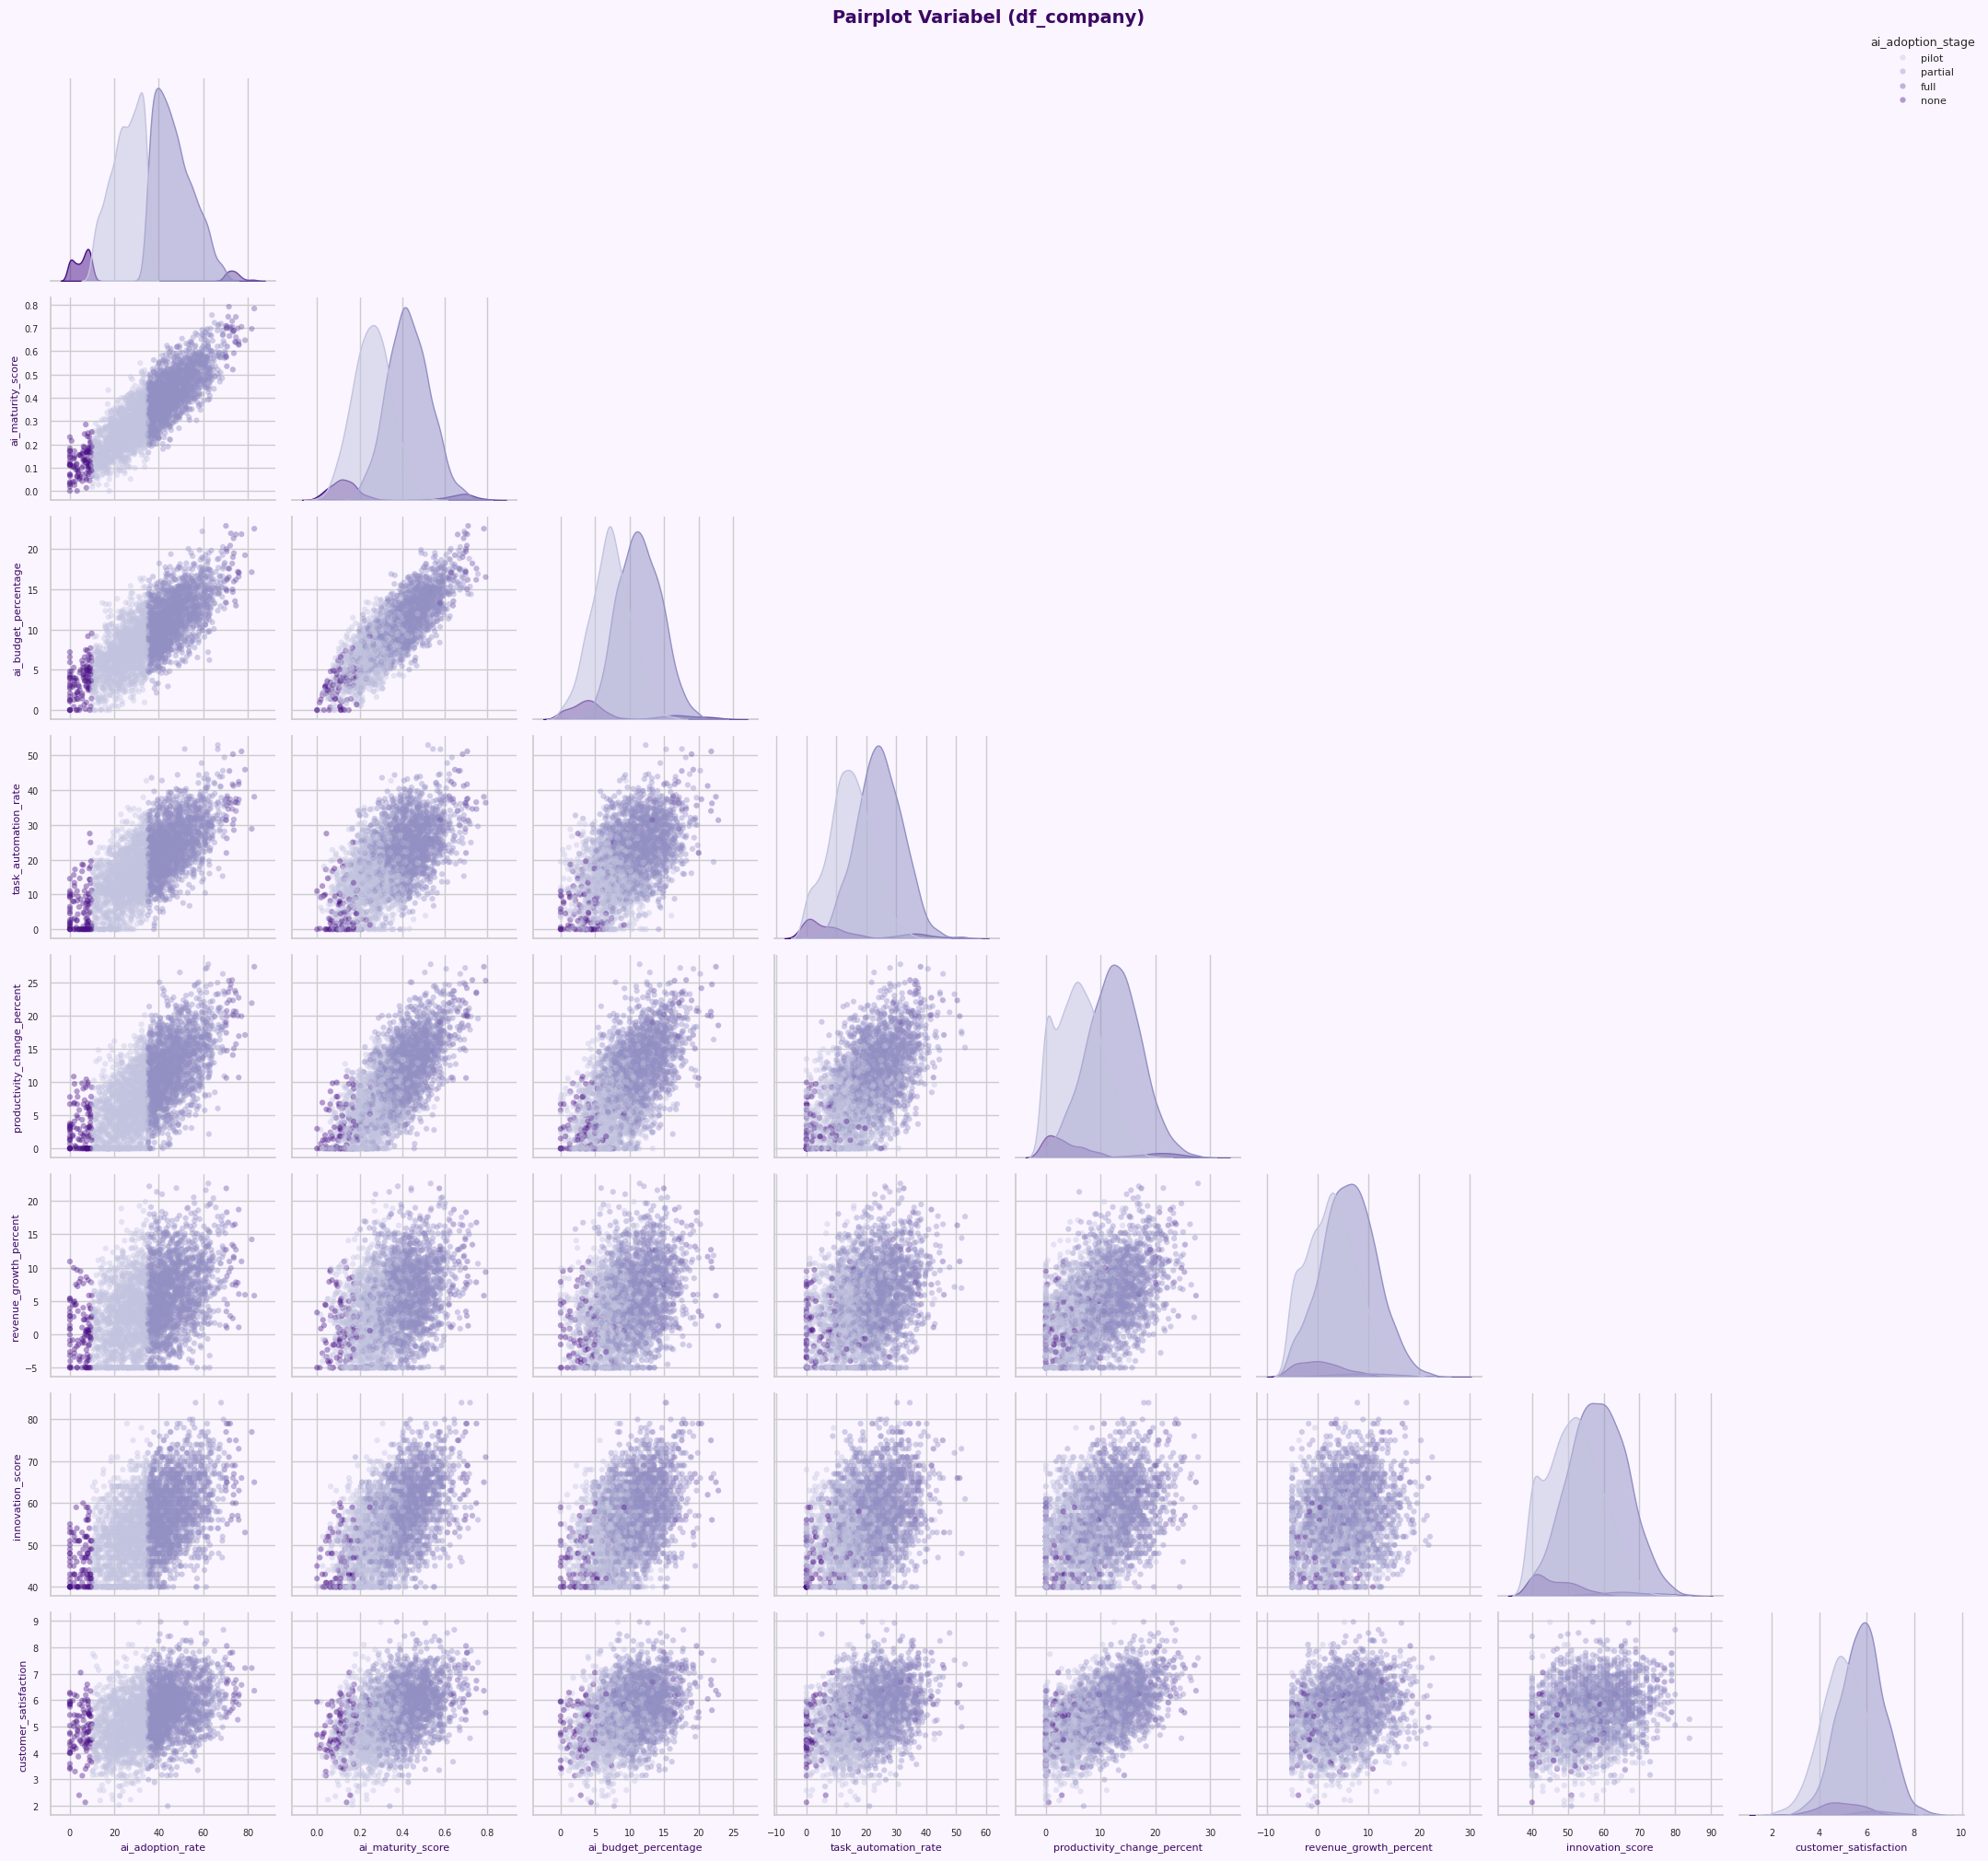

In [ ]:
# ===========================================================================================================================
# PAIRPLOT VARIABEL (df_company)
# ===========================================================================================================================

import matplotlib.colors as mcolors

pairplot_cols = [
    'ai_adoption_rate',
    'ai_maturity_score',
    'ai_budget_percentage',
    'task_automation_rate',
    'productivity_change_percent',
    'revenue_growth_percent',
    'innovation_score',
    'customer_satisfaction',
    'ai_adoption_stage'
]

sample_pair = df_clean[pairplot_cols].sample(n=3000, random_state=42)

n_stages     = sample_pair['ai_adoption_stage'].nunique()
purple_pal   = [mcolors.to_hex(c) for c in plt.cm.Purples(np.linspace(0.35, 0.95, n_stages))]

g = sns.pairplot(
    sample_pair,
    hue='ai_adoption_stage',
    palette=purple_pal,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20, 'edgecolor': 'none'},
    diag_kws={'fill': True, 'alpha': 0.5},
    corner=True
)

g.figure.patch.set_facecolor('#faf5ff')
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_facecolor('#faf5ff')
        ax.tick_params(labelsize=7)
        ax.xaxis.label.set_size(8)
        ax.yaxis.label.set_size(8)
        ax.xaxis.label.set_color(CLR_DARK)
        ax.yaxis.label.set_color(CLR_DARK)

g.figure.suptitle(
    'Pairplot Variabel (df_company)',
    fontsize=14, fontweight='bold', color=CLR_DARK, y=1.01
)

sns.move_legend(
    g, 'upper right',
    bbox_to_anchor=(1.0, 1.0),
    title='ai_adoption_stage',
    title_fontsize=9,
    fontsize=8,
    framealpha=0.7
)

plt.tight_layout()
plt.savefig('pairplot_kunci.png', dpi=150, bbox_inches='tight')
plt.show()

## **Analisis Pairplot Variabel**

Analisis ini bertujuan untuk melihat pola hubungan antarvariabel sekaligus memahami distribusi data pada masing-masing indikator yang berkaitan dengan implementasi AI. Melalui *pairplot*, hubungan linear, kekuatan korelasi, serta perbedaan persebaran antar kelompok dapat diamati secara lebih jelas.

Berdasarkan *pairplot*, terlihat bahwa beberapa variabel memiliki pola hubungan positif yang cukup jelas. Variabel seperti `ai_adoption_rate`, `ai_maturity_score`, dan `ai_budget_percentage` menunjukkan pola linear yang rapat, sehingga mengindikasikan adanya korelasi positif yang kuat antar variabel tersebut. Artinya, perusahaan dengan tingkat adopsi AI yang tinggi cenderung memiliki tingkat kematangan AI dan alokasi anggaran AI yang lebih besar.

Selain itu, hubungan positif juga terlihat pada `task_automation_rate`, `productivity_change_percent`, dan `revenue_growth_percent`. Semakin tinggi otomatisasi tugas berbasis AI, maka produktivitas dan pertumbuhan pendapatan perusahaan juga cenderung meningkat. Pada diagonal *pairplot*, distribusi data tiap variabel menunjukkan sebagian besar data terkonsentrasi di nilai tengah dengan pola distribusi yang relatif normal.

*Pairplot* juga memperlihatkan bahwa kelompok `ai_adoption_stage` memiliki persebaran data yang berbeda. Perusahaan dengan tahap adopsi AI lebih tinggi (`full`) umumnya berada pada nilai yang lebih besar dibanding tahap `pilot` atau `none`. Hal ini menunjukkan bahwa tingkat implementasi AI berpengaruh terhadap performa dan inovasi perusahaan.

Secara keseluruhan, *pairplot* membantu memperlihatkan pola hubungan antar variabel sekaligus distribusi data, sehingga dapat disimpulkan bahwa implementasi AI memiliki keterkaitan positif terhadap produktivitas, inovasi, dan pertumbuhan bisnis perusahaan.

In [ ]:
# ===========================================================================================================================
# Boxplot
# ===========================================================================================================================

import math
import numpy as np
import plotly.graph_objects as go

boxplot_configs = [
    ('ai_adoption_rate',            'ai_adoption_stage'),
    ('ai_maturity_score',           'ai_adoption_stage'),
    ('ai_budget_percentage',        'ai_adoption_stage'),
    ('ai_training_hours',           'ai_adoption_stage'),
    ('task_automation_rate',        'ai_adoption_stage'),
    ('productivity_change_percent', 'ai_adoption_stage'),
    ('revenue_growth_percent',      'ai_adoption_stage'),
    ('innovation_score',            'ai_adoption_stage'),
    ('customer_satisfaction',       'company_size'),
    ('ai_adoption_rate',            'company_size'),
    ('productivity_change_percent', 'industry'),
    ('revenue_growth_percent',      'industry'),
]

PURPLE_SHADES = ['#2e1065', '#4c1d95', '#6d28d9', '#7c3aed', '#8b5cf6', '#a78bfa', '#c4b5fd']
CLR_DARK      = '#3b0764'
CLR_MID       = '#6d28d9'
CLR_BG        = '#faf5ff'
CLR_GRID      = 'rgba(109,40,217,0.08)'


def get_purple_shades(n):
    return (PURPLE_SHADES * math.ceil(n / len(PURPLE_SHADES)))[:n]

def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip('#')
    lv = len(hex_color)
    rgb = tuple(int(hex_color[i:i + lv // 3], 16) for i in range(0, lv, lv // 3))
    return f'rgba({rgb[0]}, {rgb[1]}, {rgb[2]}, {alpha})'


all_traces = []
trace_map  = {}
trace_idx  = 0

for cfg_idx, (y_col, x_col) in enumerate(boxplot_configs):
    order      = df_company.groupby(x_col)[y_col].median().sort_values(ascending=False).index.tolist()
    categories = order
    colors     = get_purple_shades(len(categories))
    cfg_traces = []

    for cat, color in zip(categories, colors):
        subset = df_company[df_company[x_col] == cat][y_col].dropna()
        all_traces.append(go.Box(
            y=subset,
            name=str(cat),
            legendgroup=str(cat),
            marker=dict(
                color=color,
                size=3,
                opacity=0.4,
                # outliercolor=color, # Removed outliercolor to ensure no specific color for outliers
            ),
            line=dict(color=color, width=1.8),
            fillcolor=hex_to_rgba(color, 0.2),
            boxmean='sd',
            width=0.5,
            hovertemplate=(
                f'<b>{cat}</b><br>'
                'Median: %{median:.2f}<br>'
                'Q1: %{q1:.2f} — Q3: %{q3:.2f}<br>'
                'Min: %{lowerfence:.2f} — Max: %{upperfence:.2f}'
                '<extra></extra>'
            ),
            visible=(cfg_idx == 0),
            boxpoints=False, # Set to False to hide all data points, including outliers
        ))
        cfg_traces.append(trace_idx)
        trace_idx += 1

    medians = df_company.groupby(x_col)[y_col].median().reindex(order)
    annotations_cfg = []
    for j, (cat, med) in enumerate(medians.items()):
        annotations_cfg.append(dict(
            x=cat,
            y=med,
            text=f'<b>{med:.1f}</b>',
            xref='x', yref='y',
            showarrow=False,
            yanchor='bottom',
            font=dict(size=10, color=CLR_DARK),
        ))

    trace_map[cfg_idx] = dict(
        traces=cfg_traces,
        y_col=y_col,
        x_col=x_col,
        order=order,
        annotations=annotations_cfg,
    )

total_traces = trace_idx
buttons = []

for cfg_idx, info in trace_map.items():
    visible_arr = [False] * total_traces
    for t in info['traces']:
        visible_arr[t] = True

    y_label = info['y_col'].replace('_', ' ')
    x_label = info['x_col'].replace('_', ' ')

    buttons.append(dict(
        label=f"{y_label}  by  {x_label}",
        method='update',
        args=[
            {'visible': visible_arr},
            {
                'xaxis': dict(
                    title=dict(text=x_label, font=dict(size=13, color=CLR_DARK), standoff=14),
                    categoryorder='array',
                    categoryarray=info['order'],
                    showgrid=False,
                    tickfont=dict(size=11, color='#888'),
                ),
                'yaxis': dict(
                    title=dict(text=y_label, font=dict(size=13, color=CLR_DARK), standoff=14),
                    showgrid=True,
                    gridcolor=CLR_GRID,
                    zeroline=False,
                    tickfont=dict(size=11, color='#888'),
                ),
                'annotations': info['annotations'],
            },
        ],
    ))


init = trace_map[0]
fig  = go.Figure(data=all_traces)

fig.update_layout(
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.0, xanchor='left',
        y=1.13, yanchor='top',
        bgcolor='#ede9fe',
        bordercolor=CLR_MID,
        borderwidth=1,
        font=dict(size=12, color=CLR_DARK),
        pad=dict(t=4, b=4, l=6, r=6),
    )],
    annotations=[
        dict(
            text='<b>Pilih variabel :</b>',
            x=0.0, y=1.175,
            xref='paper', yref='paper',
            showarrow=False, xanchor='left',
            font=dict(size=12, color=CLR_DARK),
        ),
        *init['annotations'],
    ],
    xaxis=dict(
        title=dict(text=init['x_col'].replace('_', ' '), font=dict(size=13, color=CLR_DARK), standoff=14),
        categoryorder='array',
        categoryarray=init['order'],
        showgrid=False,
        tickfont=dict(size=11, color='#888'),
    ),
    yaxis=dict(
        title=dict(text=init['y_col'].replace('_', ' '), font=dict(size=13, color=CLR_DARK), standoff=14),
        showgrid=True,
        gridcolor=CLR_GRID,
        zeroline=False,
        tickfont=dict(size=11, color='#888'),
    ),
    legend=dict(
        title=dict(text=init['x_col'].replace('_', ' '), font=dict(size=12, color=CLR_DARK)),
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor=CLR_MID,
        borderwidth=1,
        font=dict(size=11, color=CLR_DARK),
        x=1.01, xanchor='left',
        y=1.0,  yanchor='top',
        itemsizing='constant',
        itemclick='toggleothers',
    ),
    boxmode='group',
    paper_bgcolor=CLR_BG,
    plot_bgcolor='white',
    height=560,
    width=980,
    margin=dict(t=90, b=70, l=80, r=180),
    font=dict(family='Arial, sans-serif'),
)

fig.write_html('boxplot_interaktif.html')
fig.show()

## **Analisis Boxplot**

Analisis ini bertujuan untuk membandingkan distribusi berbagai indikator bisnis berdasarkan tahap adopsi AI, ukuran perusahaan, dan jenis industri. Melalui boxplot, dapat diamati nilai median, sebaran data, serta perbedaan karakteristik antar kelompok sehingga membantu memahami pengaruh implementasi AI terhadap performa perusahaan.

Berdasarkan boxplot, terlihat bahwa perusahaan dengan tahap adopsi AI `full` memiliki nilai tertinggi pada hampir semua variabel utama, seperti `ai_adoption_rate`, `ai_maturity_score`, `ai_budget_percentage`, `ai_training_hours`, hingga `task_automation_rate`. Hal ini menunjukkan bahwa perusahaan yang telah mengimplementasikan AI secara penuh cenderung memiliki investasi, pelatihan, dan tingkat otomatisasi yang lebih tinggi dibanding tahap `partial`, `pilot`, maupun `none`.

Selain itu, variabel `productivity_change_percent`, `revenue_growth_percent`, dan `innovation_score` juga menunjukkan median yang lebih tinggi pada kelompok `full adoption`. Ini mengindikasikan bahwa implementasi AI yang lebih matang berkontribusi terhadap peningkatan produktivitas, pertumbuhan pendapatan, dan inovasi perusahaan. Sebaliknya, perusahaan pada tahap `none` memiliki nilai paling rendah pada hampir seluruh indikator.

Pada perbandingan berdasarkan `company_size`, perusahaan kategori `Enterprise` memiliki tingkat `customer_satisfaction` dan `ai_adoption_rate` yang sedikit lebih tinggi dibanding `SME` dan `Startup`. Hal ini menunjukkan bahwa perusahaan besar cenderung lebih siap dalam mengadopsi AI karena memiliki sumber daya dan anggaran yang lebih besar.

Sementara itu, berdasarkan `industry`, terlihat bahwa sektor seperti `Technology`, `Finance`, dan `Consulting` memiliki median `productivity_change_percent` serta `revenue_growth_percent` yang relatif lebih tinggi dibanding industri lain. Artinya, sektor-sektor tersebut memperoleh dampak positif yang lebih besar dari implementasi AI.

Secara keseluruhan, boxplot menunjukkan bahwa tingkat adopsi AI yang lebih tinggi berkaitan dengan peningkatan performa bisnis, produktivitas, inovasi, dan pertumbuhan perusahaan.

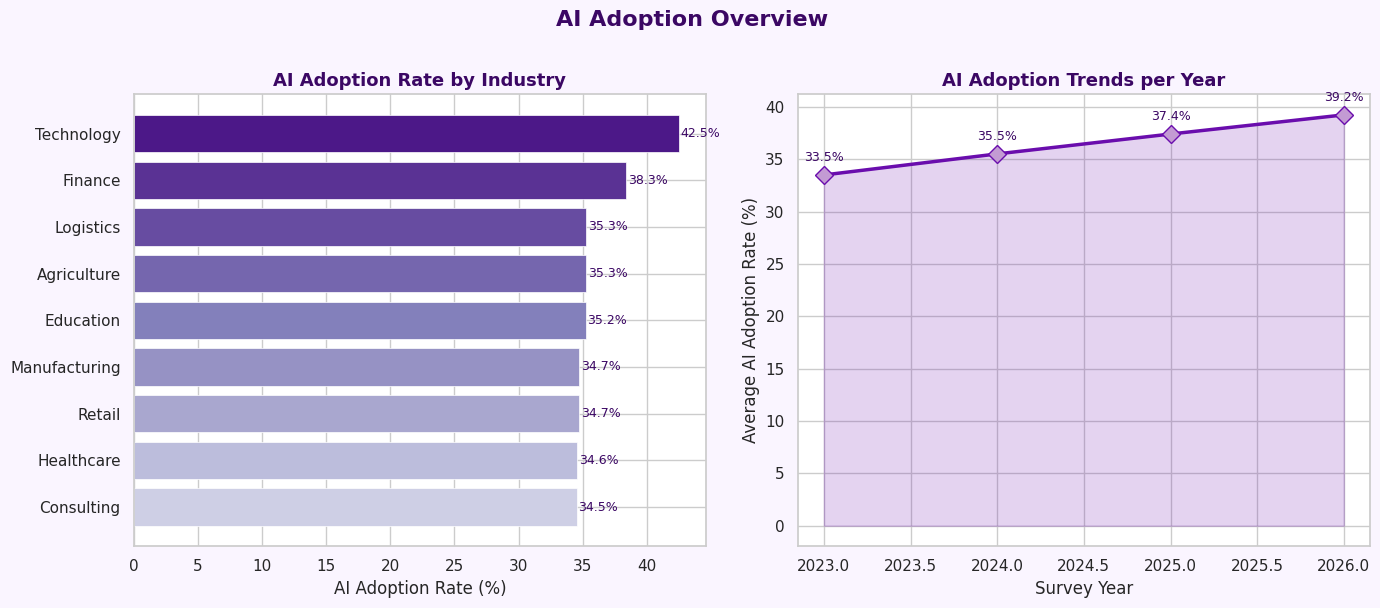

In [ ]:
# ===========================================================================================================================
# TARGET DISTRIBUTION | YEARLY TREND | AVERAGE BY INDUSTRY
# ===========================================================================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#faf5ff')

# -- Plot 1: Average AI Adoption Rate by Industry --
if 'industry' in df_clean.columns:
    ind_mean = df_clean.groupby('industry')[TARGET].mean().sort_values()
    axes[0].barh(ind_mean.index, ind_mean.values,
                 color=CLR_GRADIENT(len(ind_mean)),
                 edgecolor='white', lw=0.5)
    for i, val in enumerate(ind_mean.values):
        axes[0].text(val + 0.15, i, f'{val:.1f}%', va='center', fontsize=9, color=CLR_DARK)
    axes[0].set_title('AI Adoption Rate by Industry', fontsize=13, fontweight='bold', color=CLR_DARK)
    axes[0].set_xlabel('AI Adoption Rate (%)')

# -- Plot 2: Yearly average trend --
if 'survey_year' in df_clean.columns:
    yearly_avg = df_clean.groupby('survey_year')[TARGET].mean()
    axes[1].plot(yearly_avg.index, yearly_avg.values,
                 marker='D', color=CLR_PRIMARY, lw=2.5, ms=9, markerfacecolor=CLR_SOFT)
    axes[1].fill_between(yearly_avg.index, yearly_avg.values, alpha=0.18, color=CLR_PRIMARY)
    axes[1].set_title('AI Adoption Trends per Year', fontsize=13, fontweight='bold', color=CLR_DARK)
    axes[1].set_xlabel('Survey Year')
    axes[1].set_ylabel('Average AI Adoption Rate (%)')
    for xv, yv in zip(yearly_avg.index, yearly_avg.values):
        axes[1].annotate(f'{yv:.1f}%', (xv, yv),
                         textcoords='offset points', xytext=(0, 10),
                         ha='center', fontsize=9, color=CLR_DARK)

plt.suptitle('AI Adoption Overview', fontsize=16, fontweight='bold', color=CLR_DARK, y=1.01)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## **Analisis AI Adoption Overview**

Analisis ini bertujuan untuk memberikan gambaran umum mengenai tingkat adopsi AI berdasarkan industri serta perkembangannya dari tahun ke tahun. Visualisasi ini membantu memahami sektor industri yang paling aktif mengimplementasikan AI sekaligus melihat tren pertumbuhan penggunaan AI secara keseluruhan.

Berdasarkan grafik **AI Adoption Rate by Industry**, sektor `Technology` memiliki tingkat adopsi AI tertinggi sebesar **42.5%**, diikuti oleh `Finance` sebesar **38.3%**. Sementara itu, industri lain seperti `Logistics`, `Agriculture`, `Education`, hingga `Healthcare` memiliki tingkat adopsi yang relatif mirip, yaitu berada di kisaran **34%-35%**. Hal ini menunjukkan bahwa sektor teknologi dan keuangan menjadi industri yang paling cepat dalam mengimplementasikan AI karena kebutuhan inovasi dan otomatisasi yang tinggi.

Pada grafik **AI Adoption Trends per Year**, terlihat adanya peningkatan rata-rata adopsi AI setiap tahun. Tingkat adopsi meningkat dari **33.5% pada 2023** menjadi **39.2% pada 2026**. Tren ini menunjukkan bahwa penggunaan AI terus berkembang dan semakin banyak perusahaan mulai mengintegrasikan teknologi AI ke dalam proses bisnis mereka.

Secara keseluruhan, visualisasi ini menggambarkan bahwa adopsi AI mengalami pertumbuhan yang konsisten dari tahun ke tahun, dengan sektor teknologi menjadi pemimpin utama dalam implementasi AI dibanding industri lainnya.

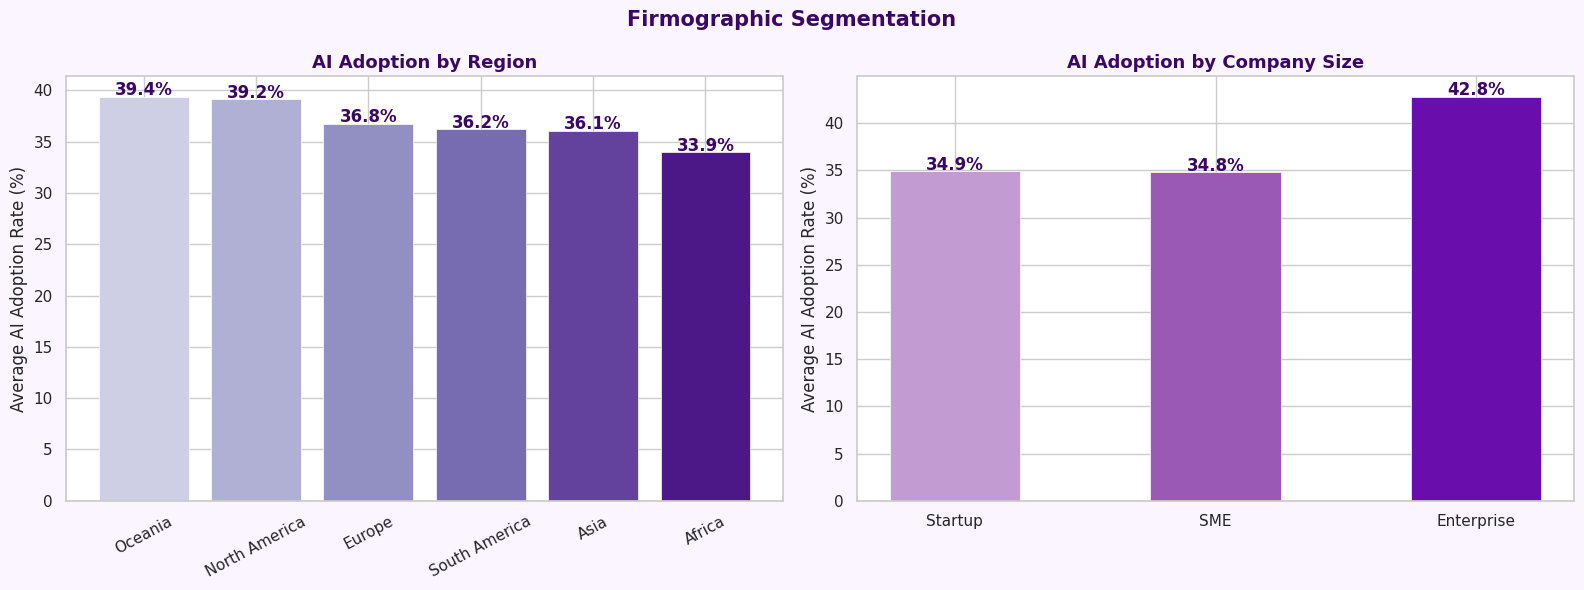

In [ ]:
# ===========================================================================================================================
# COMPANY SEGMENTATION | SIZE & REGION
# ===========================================================================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#faf5ff')

# -- Plot 1: AI Adoption by Region --
if 'region' in df_clean.columns:
    region_avg = df_clean.groupby('region')[TARGET].mean().sort_values(ascending=False)
    axes[0].bar(region_avg.index, region_avg.values,
                color=CLR_GRADIENT(len(region_avg)),
                edgecolor='white', lw=0.5)
    axes[0].set_title('AI Adoption by Region', fontsize=13, fontweight='bold', color=CLR_DARK)
    axes[0].set_ylabel('Average AI Adoption Rate (%)')
    axes[0].tick_params(axis='x', rotation=28)
    for idx, val in enumerate(region_avg.values):
        axes[0].text(idx, val + 0.15, f'{val:.1f}%', ha='center', fontweight='bold', color=CLR_DARK)

# -- Plot 2: AI Adoption by Company Size --
if 'company_size' in df_clean.columns:
    size_order   = [s for s in ['Startup', 'SME', 'Enterprise'] if s in df_clean['company_size'].unique()]
    size_avg     = df_clean.groupby('company_size')[TARGET].mean().reindex(size_order)
    palette_size = [CLR_SOFT, CLR_SECONDARY, CLR_PRIMARY][:len(size_avg)]
    axes[1].bar(size_avg.index, size_avg.values,
                color=palette_size, edgecolor='white', lw=0.5, width=0.5)
    axes[1].set_title('AI Adoption by Company Size', fontsize=13, fontweight='bold', color=CLR_DARK)
    axes[1].set_ylabel('Average AI Adoption Rate (%)')
    for idx, val in enumerate(size_avg.values):
        axes[1].text(idx, val + 0.15, f'{val:.1f}%', ha='center', fontweight='bold', color=CLR_DARK)

plt.suptitle('Firmographic Segmentation', fontsize=15, fontweight='bold', color=CLR_DARK)
plt.tight_layout()
plt.savefig('eda_firmographic.png', dpi=150, bbox_inches='tight')
plt.show()

## **Firmographic Segmentation Analysis**

Analisis ini bertujuan untuk melihat perbedaan tingkat adopsi AI berdasarkan karakteristik perusahaan dan wilayah geografis. Visualisasi ini membantu memahami bagaimana faktor regional serta ukuran perusahaan memengaruhi implementasi AI dan mengidentifikasi kelompok yang memiliki tingkat adopsi AI paling tinggi maupun rendah.

Berdasarkan visualisasi di atas, tingkat adopsi AI berdasarkan wilayah menunjukkan bahwa Oceania memiliki rata-rata adopsi AI tertinggi sebesar 39,4%, diikuti North America sebesar 39,2%. Sementara itu, Africa memiliki tingkat adopsi paling rendah yaitu 33,9%. Perbedaan ini menunjukkan bahwa perkembangan teknologi AI di beberapa wilayah maju cenderung lebih tinggi dibandingkan wilayah berkembang.

Selain itu, berdasarkan ukuran perusahaan, *Enterprise* memiliki tingkat adopsi AI tertinggi sebesar 42,8%, jauh lebih tinggi dibandingkan *Startup* dan *SME* yang masing-masing berada di sekitar 34%. Hal ini menunjukkan bahwa perusahaan besar memiliki sumber daya dan infrastruktur yang lebih mendukung untuk mengimplementasikan teknologi AI dalam operasional bisnis mereka.

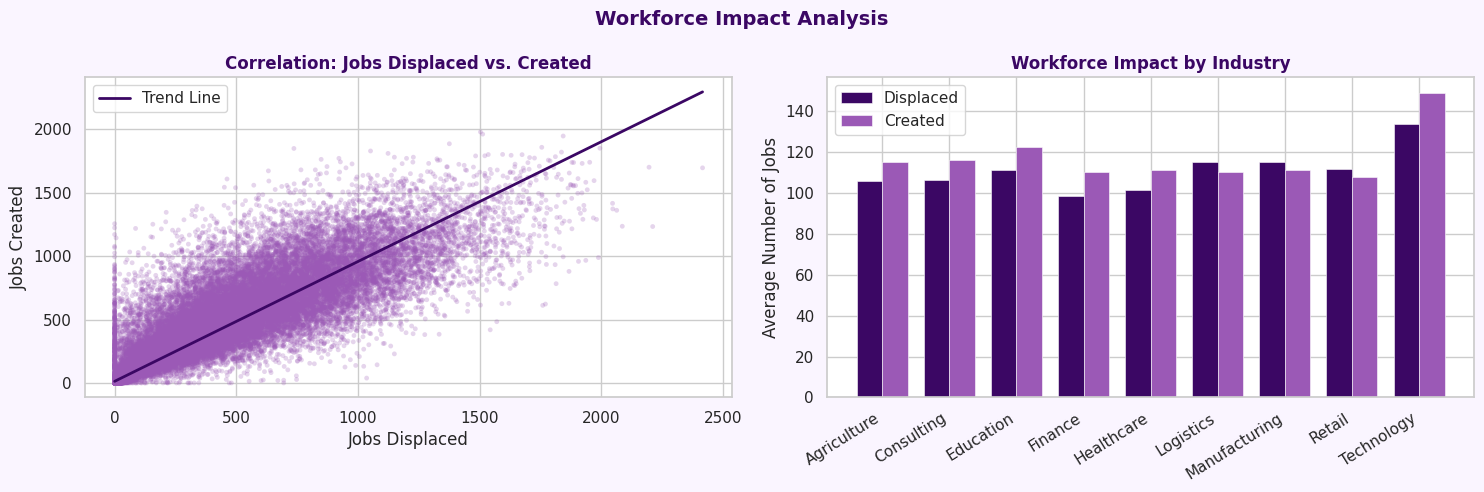

In [ ]:
# ===========================================================================================================================
# WORKFORCE IMPACT | JOBS DISPLACED VS CREATED
# ===========================================================================================================================
if 'jobs_displaced' in df_clean.columns and 'jobs_created' in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.patch.set_facecolor('#faf5ff')

    # -- Plot 1: Scatter jobs displaced vs created --
    axes[0].scatter(df_clean['jobs_displaced'], df_clean['jobs_created'],
                    alpha=0.25, s=12, color=CLR_SECONDARY, edgecolors='none')
    coef    = np.polyfit(df_clean['jobs_displaced'], df_clean['jobs_created'], 1)
    x_range = np.linspace(df_clean['jobs_displaced'].min(), df_clean['jobs_displaced'].max(), 120)
    axes[0].plot(x_range, np.poly1d(coef)(x_range), color=CLR_DARK, lw=2, label='Trend Line')
    axes[0].set_xlabel('Jobs Displaced')
    axes[0].set_ylabel('Jobs Created')
    axes[0].set_title('Correlation: Jobs Displaced vs. Created', fontsize=12, fontweight='bold', color=CLR_DARK)
    axes[0].legend()

    # -- Plot 2: Grouped bar by industry --
    if 'industry' in df_clean.columns:
        workforce_by_industry = df_clean.groupby('industry')[['jobs_displaced', 'jobs_created']].mean()
        x_pos, bar_w          = np.arange(len(workforce_by_industry)), 0.38
        axes[1].bar(x_pos - bar_w/2, workforce_by_industry['jobs_displaced'], bar_w,
                    label='Displaced', color=CLR_DARK,     edgecolor='white', lw=0.4)
        axes[1].bar(x_pos + bar_w/2, workforce_by_industry['jobs_created'],   bar_w,
                    label='Created',   color=CLR_SECONDARY, edgecolor='white', lw=0.4)
        axes[1].set_xticks(x_pos)
        axes[1].set_xticklabels(workforce_by_industry.index, rotation=32, ha='right')
        axes[1].set_title('Workforce Impact by Industry', fontsize=12, fontweight='bold', color=CLR_DARK)
        axes[1].set_ylabel('Average Number of Jobs')
        axes[1].legend()

    plt.suptitle('Workforce Impact Analysis', fontsize=14, fontweight='bold', color=CLR_DARK)
    plt.tight_layout()
    plt.savefig('eda_workforce.png', dpi=150, bbox_inches='tight')
    plt.show()

## **Workforce Impact Analysis**

Analisis ini bertujuan untuk memahami dampak penerapan AI terhadap tenaga kerja dengan membandingkan jumlah pekerjaan yang tergantikan (*jobs displaced*) dan pekerjaan baru yang tercipta (*jobs created*). Visualisasi ini membantu melihat apakah perkembangan AI lebih banyak menggantikan pekerjaan atau justru membuka peluang kerja baru pada berbagai sektor industri.

Berdasarkan visualisasi di atas, terdapat hubungan positif antara jumlah pekerjaan yang tergantikan (*jobs displaced*) dan pekerjaan baru yang tercipta (*jobs created*). Hal ini terlihat dari pola *scatter plot* dan *trend line* yang terus meningkat, sehingga dapat disimpulkan bahwa perkembangan AI tidak hanya menggantikan pekerjaan, tetapi juga menciptakan peluang kerja baru di berbagai sektor.

Selain itu, pada analisis berdasarkan industri, sektor *Technology* memiliki rata-rata jumlah pekerjaan tercipta paling tinggi dibandingkan industri lainnya. Sementara beberapa sektor seperti *Logistics*, *Manufacturing*, dan *Retail* menunjukkan jumlah pekerjaan yang tergantikan sedikit lebih besar dibandingkan pekerjaan baru yang tercipta. Kondisi ini menunjukkan bahwa dampak AI terhadap tenaga kerja berbeda-beda tergantung karakteristik masing-masing industri.

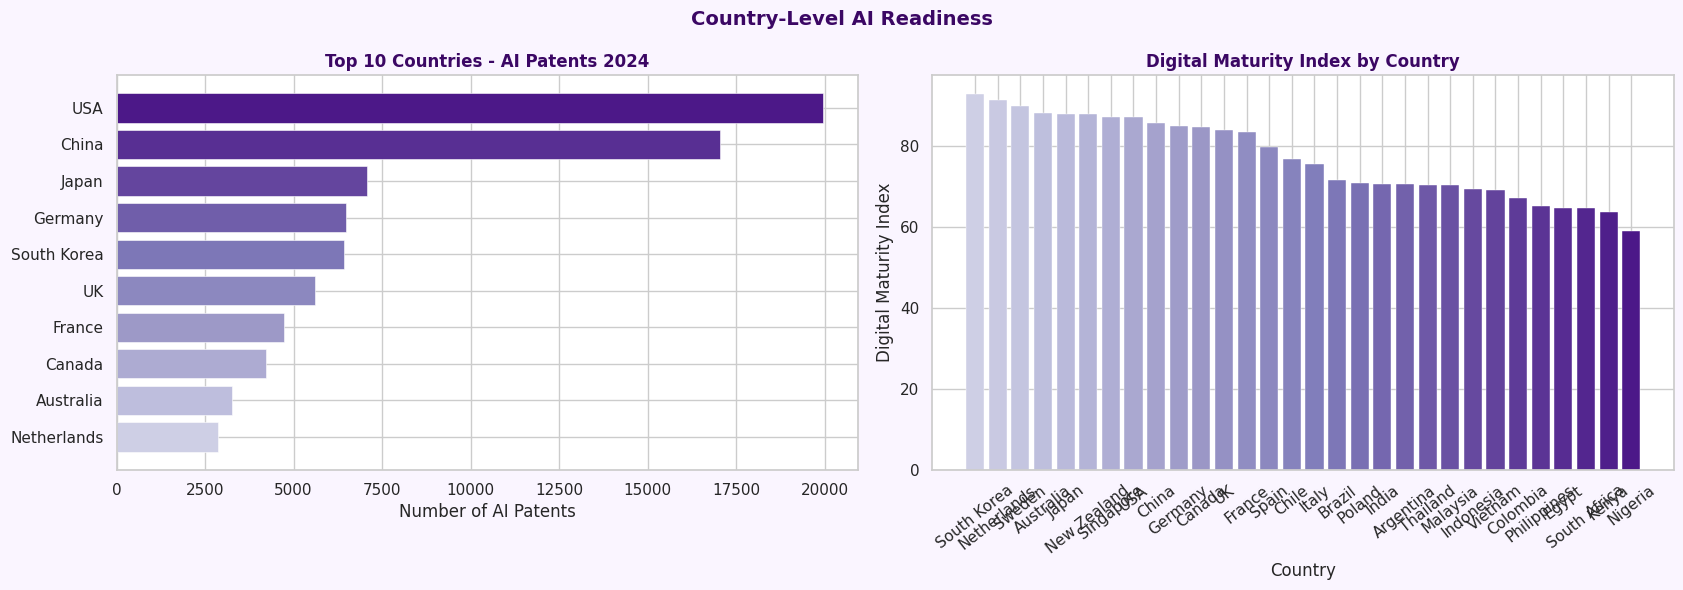

In [ ]:
# ===========================================================================================================================
# COUNTRY READINESS | DIGITAL MATURITY & AI PATENTS
# ===========================================================================================================================
if df_country is not None:
    fig, axes = plt.subplots(1, 2, figsize=(17, 6))
    fig.patch.set_facecolor('#faf5ff')

    # -- Plot 1: Top 10 AI patent filings --
    top10_patent = df_country.nlargest(10, 'ai_patent_filings_2024').sort_values('ai_patent_filings_2024')
    axes[0].barh(top10_patent['country'], top10_patent['ai_patent_filings_2024'],
                 color=CLR_GRADIENT(10), edgecolor='white', lw=0.4)
    axes[0].set_title('Top 10 Countries - AI Patents 2024', fontsize=12, fontweight='bold', color=CLR_DARK)
    axes[0].set_xlabel('Number of AI Patents')

    # -- Plot 2: Digital maturity index --
    df_sorted_dm = df_country.sort_values('digital_maturity_index', ascending=False)
    axes[1].bar(df_sorted_dm['country'], df_sorted_dm['digital_maturity_index'],
                color=CLR_GRADIENT(len(df_sorted_dm)), edgecolor='white', lw=0.3)
    axes[1].set_title('Digital Maturity Index by Country', fontsize=12, fontweight='bold', color=CLR_DARK)
    axes[1].set_xlabel('Country')
    axes[1].set_ylabel('Digital Maturity Index')
    axes[1].tick_params(axis='x', rotation=38)

    plt.suptitle('Country-Level AI Readiness', fontsize=14, fontweight='bold', color=CLR_DARK)
    plt.tight_layout()
    plt.savefig('eda_countries.png', dpi=150, bbox_inches='tight')
    plt.show()

## **Country-Level AI Readiness**

Analisis ini bertujuan untuk menilai kesiapan suatu negara dalam mengembangkan dan mengadopsi teknologi AI melalui indikator inovasi serta kematangan digital. Visualisasi ini membantu membandingkan kemampuan negara dalam menghasilkan inovasi AI, seperti jumlah paten, serta melihat hubungan antara kesiapan digital dan perkembangan teknologi AI.

Berdasarkan visualisasi di atas, USA menjadi negara dengan jumlah paten AI tertinggi pada tahun 2024, mencapai sekitar 20.000 paten, diikuti oleh China dengan sekitar 17.000 paten. Jepang, Jerman, dan South Korea juga termasuk dalam negara dengan kontribusi besar dalam inovasi AI. Hal ini menunjukkan bahwa negara-negara maju memiliki dominasi yang kuat dalam pengembangan teknologi kecerdasan buatan.

Selain itu, pada *Digital Maturity Index*, South Korea memiliki tingkat kematangan digital tertinggi dibandingkan negara lainnya. Beberapa negara seperti Sweden, Australia, dan Japan juga menunjukkan indeks yang tinggi, sedangkan Nigeria memiliki nilai paling rendah. Data ini menunjukkan bahwa kesiapan digital suatu negara berpengaruh terhadap kemampuan adopsi dan pengembangan teknologi AI secara lebih optimal.

In [ ]:
# ===========================================================================================================================
# MOST POPULAR AI TOOLS | TOP 10 TOOLS USED
# ===========================================================================================================================

import plotly.graph_objects as go

CLR_DARK     = '#3b0764'
CLR_MID      = '#6d28d9'
CLR_BG       = '#faf5ff'
CLR_GRID     = 'rgba(109,40,217,0.08)'
PURPLE_SCALE = [
    '#2e1065', '#4c1d95', '#5b21b6', '#6d28d9',
    '#7c3aed', '#8b5cf6', '#a78bfa', '#c4b5fd', '#ddd6fe', '#ede9fe',
]

if 'ai_primary_tool' in df_company.columns:
    top_tools = df_company['ai_primary_tool'].value_counts().head(10)
    tools     = top_tools.index.tolist()
    counts    = top_tools.values.tolist()
    colors    = PURPLE_SCALE[:len(tools)]

    fig = go.Figure(go.Bar(
        x=tools,
        y=counts,
        marker=dict(
            color=colors,
            line=dict(color='white', width=0.6),
        ),
        text=[str(v) for v in counts],
        textposition='outside',
        textfont=dict(size=11, color=CLR_DARK, family='Arial, sans-serif'),
        hovertemplate='<b>%{x}</b><br>Perusahaan: %{y:,}<extra></extra>',
        width=0.6,
    ))

    fig.update_layout(
        xaxis=dict(
            title=dict(text='Tool Name', font=dict(size=13, color=CLR_DARK), standoff=12),
            tickangle=-28,
            tickfont=dict(size=11, color='#555'),
            showgrid=False,
            categoryorder='total descending',
        ),
        yaxis=dict(
            title=dict(text='Number of Companies', font=dict(size=13, color=CLR_DARK), standoff=12),
            showgrid=True,
            gridcolor=CLR_GRID,
            zeroline=False,
            tickfont=dict(size=11, color='#888'),
            range=[0, max(counts) * 1.13],
        ),
        paper_bgcolor=CLR_BG,
        plot_bgcolor='white',
        height=480,
        width=900,
        margin=dict(t=70, b=90, l=70, r=40),
        font=dict(family='Arial, sans-serif'),
        title=dict(
            text='<b>Top 10 Most Popular AI Tools Among Companies</b>',
            x=0.5,
            xanchor='center',
            font=dict(size=15, color=CLR_DARK),
            pad=dict(b=16),
        ),
        showlegend=False,
    )

    fig.write_html('top10_ai_tools.html')
    fig.show()

## **Popular AI Tools Among Companies**

Analisis ini bertujuan untuk mengetahui tools AI yang paling banyak digunakan oleh perusahaan serta memahami preferensi perusahaan dalam memilih teknologi AI untuk mendukung aktivitas bisnis. Visualisasi ini membantu melihat tingkat popularitas berbagai tools AI dan menunjukkan kecenderungan penggunaan teknologi AI di lingkungan perusahaan.

Berdasarkan visualisasi di atas, ChatGPT menjadi *tools* AI paling populer yang digunakan perusahaan dengan jumlah penggunaan mencapai lebih dari 46 ribu perusahaan. Posisi berikutnya ditempati oleh Claude, *Custom Internal AI*, dan Gemini dengan jumlah penggunaan yang relatif berdekatan. Sementara itu, GitHub Copilot juga cukup banyak digunakan, terutama untuk membantu proses pengembangan perangkat lunak.

Selain itu, tingginya penggunaan ChatGPT menunjukkan bahwa perusahaan cenderung memilih *tools* AI yang mudah diakses, fleksibel, dan dapat digunakan untuk berbagai kebutuhan bisnis. Di sisi lain, cukup banyak perusahaan yang mulai mengembangkan *Custom Internal AI* sebagai solusi yang lebih spesifik dan sesuai dengan kebutuhan internal organisasi mereka.

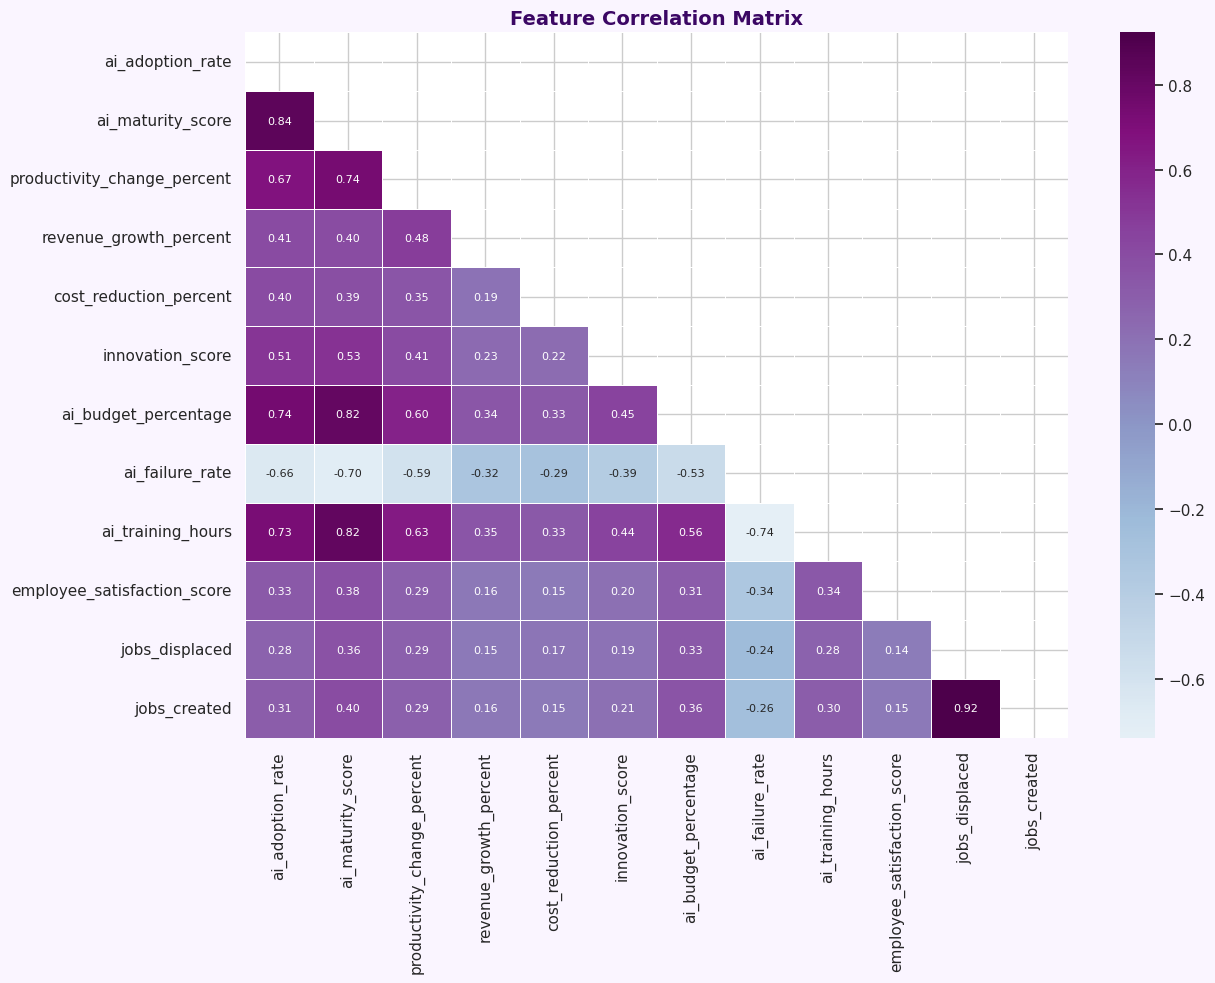

In [ ]:
# ===========================================================================================================================
# CORRELATION MATRIX | RELATIONSHIP BETWEEN KEY FEATURES
# ===========================================================================================================================
feature_pool = [
    'ai_adoption_rate', 'ai_maturity_score', 'productivity_change_percent',
    'revenue_growth_percent', 'cost_reduction_percent', 'innovation_score',
    'ai_budget_percentage', 'ai_failure_rate', 'ai_training_hours',
    'employee_satisfaction_score', 'jobs_displaced', 'jobs_created',
    'digital_maturity_index', 'gdp_per_capita', 'internet_penetration'
]
selected_features = [col for col in feature_pool if col in df_clean.columns][:15]

if len(selected_features) >= 4:
    fig, ax = plt.subplots(figsize=(13, 10))
    fig.patch.set_facecolor('#faf5ff')

    corr_matrix = df_clean[selected_features].corr()
    upper_mask  = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=upper_mask, annot=True, fmt='.2f',
                cmap=HEATMAP_CMAP, center=0, linewidths=0.6,
                ax=ax, annot_kws={'size': 8}, linecolor='white')
    ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', color=CLR_DARK)
    plt.tight_layout()
    plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()

## **Feature Correlation Matrix Analysis**

Analisis ini bertujuan untuk mengidentifikasi hubungan antarvariabel dalam implementasi AI serta mengetahui faktor-faktor yang memiliki pengaruh kuat terhadap tingkat adopsi dan keberhasilan AI. Dengan menggunakan *correlation matrix*, hubungan positif maupun negatif antarfitur dapat terlihat sehingga membantu memahami pola data secara lebih menyeluruh.

Berdasarkan *heatmap* korelasi di atas, terdapat hubungan positif yang kuat antara `ai_adoption_rate` dan `ai_maturity_score` dengan nilai korelasi sebesar 0,84. Selain itu, `ai_budget_percentage` dan `ai_training_hours` juga memiliki korelasi tinggi terhadap tingkat kematangan AI perusahaan. Hal ini menunjukkan bahwa perusahaan yang mengalokasikan lebih banyak anggaran serta pelatihan AI cenderung memiliki tingkat adopsi dan kesiapan AI yang lebih baik.

Di sisi lain, `ai_failure_rate` memiliki korelasi negatif terhadap sebagian besar variabel utama, seperti `ai_training_hours` (-0,74) dan `ai_maturity_score` (-0,70). Artinya, semakin tinggi tingkat pelatihan dan kematangan AI perusahaan, maka kemungkinan kegagalan implementasi AI akan semakin rendah. Selain itu, hubungan sangat kuat antara `jobs_displaced` dan `jobs_created` (0,92) menunjukkan bahwa perkembangan AI tidak hanya menggantikan pekerjaan lama, tetapi juga menciptakan peluang pekerjaan baru secara signifikan.

In [ ]:
# ===========================================================================================================================
# INDUSTRY SUMMARY DEEP DIVE
# ===========================================================================================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

CLR_DARK = '#2E1065'
CLR_SECONDARY = '#5B21B6'
CLR_PRIMARY = '#7C3AED'
CLR_SOFT = '#A78BFA'
CLR_LIGHT = '#DDD6FE'
CLR_BG = '#F5F3FF'

def CLR_GRADIENT(n):
    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list(
        'purple_gradient',
        [CLR_DARK, CLR_SECONDARY, CLR_PRIMARY, CLR_SOFT],
        N=n
    )
    return [cmap(i / max(n - 1, 1)) for i in range(n)]

df_industry = pd.DataFrame({
    'industry': [
        'Healthcare', 'Finance', 'Manufacturing', 'Retail',
        'Education', 'Technology', 'Transportation', 'Energy'
    ],
    'avg_jobs_displaced': [1820, 2450, 3100, 1560, 980, 870, 2200, 1340],
    'avg_jobs_created': [1240, 1890, 1670, 1200, 1050, 1530, 1480, 980],
    'avg_ai_adoption_rate': [61.2, 74.5, 58.3, 66.8, 44.1, 82.4, 55.7, 49.3],
    'avg_ai_maturity_score': [3.42, 4.11, 3.78, 3.55, 2.97, 4.63, 3.21, 3.08],
    'avg_productivity_change_percent': [12.4, 18.7, 21.3, 14.6, 9.8, 24.1, 16.2, 11.5],
    'avg_ai_failure_rate': [18.3, 14.2, 22.7, 16.8, 25.4, 10.1, 20.3, 23.6],
    'avg_customer_satisfaction': [3.82, 4.01, 3.67, 3.94, 3.55, 4.28, 3.73, 3.61],
})

METRICS = {
    'Jobs Displaced vs Created': 'jobs',
    'AI Adoption Rate (%)': 'adoption',
    'AI Maturity Score': 'maturity',
    'Productivity Change (%)': 'productivity',
    'AI Failure Rate (%)': 'failure',
    'Customer Satisfaction': 'satisfaction',
}

metric_toggle = widgets.ToggleButtons(
    options=list(METRICS.keys()),
    layout=widgets.Layout(margin='0 0 12px 0')
)

sort_toggle = widgets.ToggleButtons(
    options=['Ascending', 'Descending', 'Alphabetical'],
    description='Sort:',
    layout=widgets.Layout(margin='0 0 16px 0')
)

filter_select = widgets.SelectMultiple(
    options=list(df_industry['industry']),
    value=list(df_industry['industry']),
    description='Industries:',
    layout=widgets.Layout(height='160px', width='320px')
)

show_values_cb = widgets.Checkbox(
    value=True,
    description='Show value labels'
)

save_btn = widgets.Button(
    description='💾 Save PNG',
    button_style='info'
)

output_area = widgets.Output()

def draw_chart(metric_label, sort_order, selected_industries, show_values):
    metric_key = METRICS[metric_label]
    df = df_industry[df_industry['industry'].isin(selected_industries)].copy()

    sort_map = {
        'jobs': 'avg_jobs_displaced',
        'adoption': 'avg_ai_adoption_rate',
        'maturity': 'avg_ai_maturity_score',
        'productivity': 'avg_productivity_change_percent',
        'failure': 'avg_ai_failure_rate',
        'satisfaction': 'avg_customer_satisfaction'
    }

    if sort_order == 'Ascending':
        df = df.sort_values(sort_map[metric_key], ascending=True)
    elif sort_order == 'Descending':
        df = df.sort_values(sort_map[metric_key], ascending=False)
    else:
        df = df.sort_values('industry')

    n = len(df)
    h = max(4, n * 0.55 + 1.5)
    bar_w = 0.38

    fig, ax = plt.subplots(figsize=(10, h))
    fig.patch.set_facecolor(CLR_BG)
    ax.set_facecolor(CLR_BG)

    x_pos = np.arange(n)
    colors = CLR_GRADIENT(n)

    if metric_key == 'jobs':
        bars_d = ax.barh(x_pos - bar_w/2, df['avg_jobs_displaced'], bar_w, color=CLR_DARK)
        bars_c = ax.barh(x_pos + bar_w/2, df['avg_jobs_created'], bar_w, color=CLR_PRIMARY)

        if show_values:
            for bar in bars_d:
                ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2, f'{bar.get_width():,.0f}', va='center')
            for bar in bars_c:
                ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2, f'{bar.get_width():,.0f}', va='center')

        ax.legend(['Displaced', 'Created'])
        ax.set_xlabel('Average Number of Jobs')

    elif metric_key == 'adoption':
        vals = df['avg_ai_adoption_rate'].values
        ax.barh(x_pos, vals, color=colors)

        if show_values:
            for i, v in enumerate(vals):
                ax.text(v+0.3, i, f'{v:.1f}%', va='center')

        ax.set_xlabel('AI Adoption Rate (%)')

    elif metric_key == 'maturity':
        vals = df['avg_ai_maturity_score'].values
        ax.barh(x_pos, vals, color=colors)

        if show_values:
            for i, v in enumerate(vals):
                ax.text(v+0.02, i, f'{v:.2f}', va='center')

        ax.set_xlabel('AI Maturity Score')

    elif metric_key == 'productivity':
        vals = df['avg_productivity_change_percent'].values
        ax.barh(x_pos, vals, color=CLR_PRIMARY)

        if show_values:
            for i, v in enumerate(vals):
                ax.text(v+0.1, i, f'{v:.1f}%', va='center')

        ax.set_xlabel('Productivity Change (%)')

    elif metric_key == 'failure':
        vals = df['avg_ai_failure_rate'].values
        bar_colors = [CLR_DARK if v >= np.mean(vals) else CLR_PRIMARY for v in vals]
        ax.barh(x_pos, vals, color=bar_colors)
        ax.axvline(np.mean(vals), color=CLR_SECONDARY, linestyle='--')

        if show_values:
            for i, v in enumerate(vals):
                ax.text(v+0.1, i, f'{v:.1f}%', va='center')

        ax.set_xlabel('AI Failure Rate (%)')

    else:
        vals = df['avg_customer_satisfaction'].values
        ax.barh(x_pos, vals, color=colors)

        if show_values:
            for i, v in enumerate(vals):
                ax.text(v+0.01, i, f'{v:.2f}', va='center')

        ax.set_xlabel('Customer Satisfaction Score')

    ax.set_yticks(x_pos)
    ax.set_yticklabels(df['industry'])
    ax.set_title(metric_label, fontsize=13, fontweight='bold', color=CLR_DARK)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    plt.tight_layout()
    return fig

def update(_=None):
    with output_area:
        clear_output(wait=True)
        if not filter_select.value:
            print('Pilih minimal satu industri.')
            return
        fig = draw_chart(
            metric_toggle.value,
            sort_toggle.value,
            list(filter_select.value),
            show_values_cb.value
        )
        plt.show()

def save_png(_):
    fig = draw_chart(
        metric_toggle.value,
        sort_toggle.value,
        list(filter_select.value),
        show_values_cb.value
    )
    fig.savefig('industry_summary_interactive.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

metric_toggle.observe(update, names='value')
sort_toggle.observe(update, names='value')
filter_select.observe(update, names='value')
show_values_cb.observe(update, names='value')
save_btn.on_click(save_png)

controls = widgets.VBox([
    widgets.HTML('<b style="font-size:15px;color:#2E1065">AI Industry Summary</b>'),
    metric_toggle,
    widgets.HBox([sort_toggle, show_values_cb]),
    widgets.HBox([
        widgets.VBox([filter_select]),
        save_btn
    ])
])

display(controls, output_area)
update()

Output()

## **AI Adoption Summary by Industry**

Analisis ini bertujuan untuk membandingkan tingkat adopsi AI antarindustri serta melihat dampaknya terhadap berbagai indikator bisnis, seperti *maturity score*, produktivitas, tingkat kegagalan implementasi, jumlah pekerjaan yang tergantikan, dan kepuasan pelanggan. Visualisasi ini membantu memahami sektor industri mana yang paling siap dalam mengimplementasikan AI serta bagaimana pengaruhnya terhadap performa bisnis.

Berdasarkan visualisasi data di atas, industri teknologi memiliki tingkat adopsi AI paling tinggi dibanding sektor lainnya, dengan rata-rata *adoption rate* sekitar 42,5% serta *maturity score* tertinggi. Hal ini menunjukkan bahwa sektor teknologi sudah lebih siap dalam memanfaatkan AI untuk mendukung operasional dan inovasi bisnis. Selain itu, produktivitas pada sektor ini juga mengalami peningkatan terbesar meskipun terdapat jumlah pekerjaan yang tergantikan cukup tinggi.

Sementara itu, sektor lain seperti *finance*, *logistics*, dan *manufacturing* juga menunjukkan perkembangan adopsi AI yang cukup baik dengan rata-rata produktivitas meningkat sekitar 8-10%. Namun, tingkat kegagalan implementasi AI di beberapa sektor masih relatif tinggi, yaitu sekitar 23-26%. Dari sisi kepuasan pelanggan, seluruh industri menunjukkan nilai yang cukup stabil di atas skor 5, yang menandakan bahwa penerapan AI secara umum memberikan dampak positif terhadap pengalaman pelanggan.

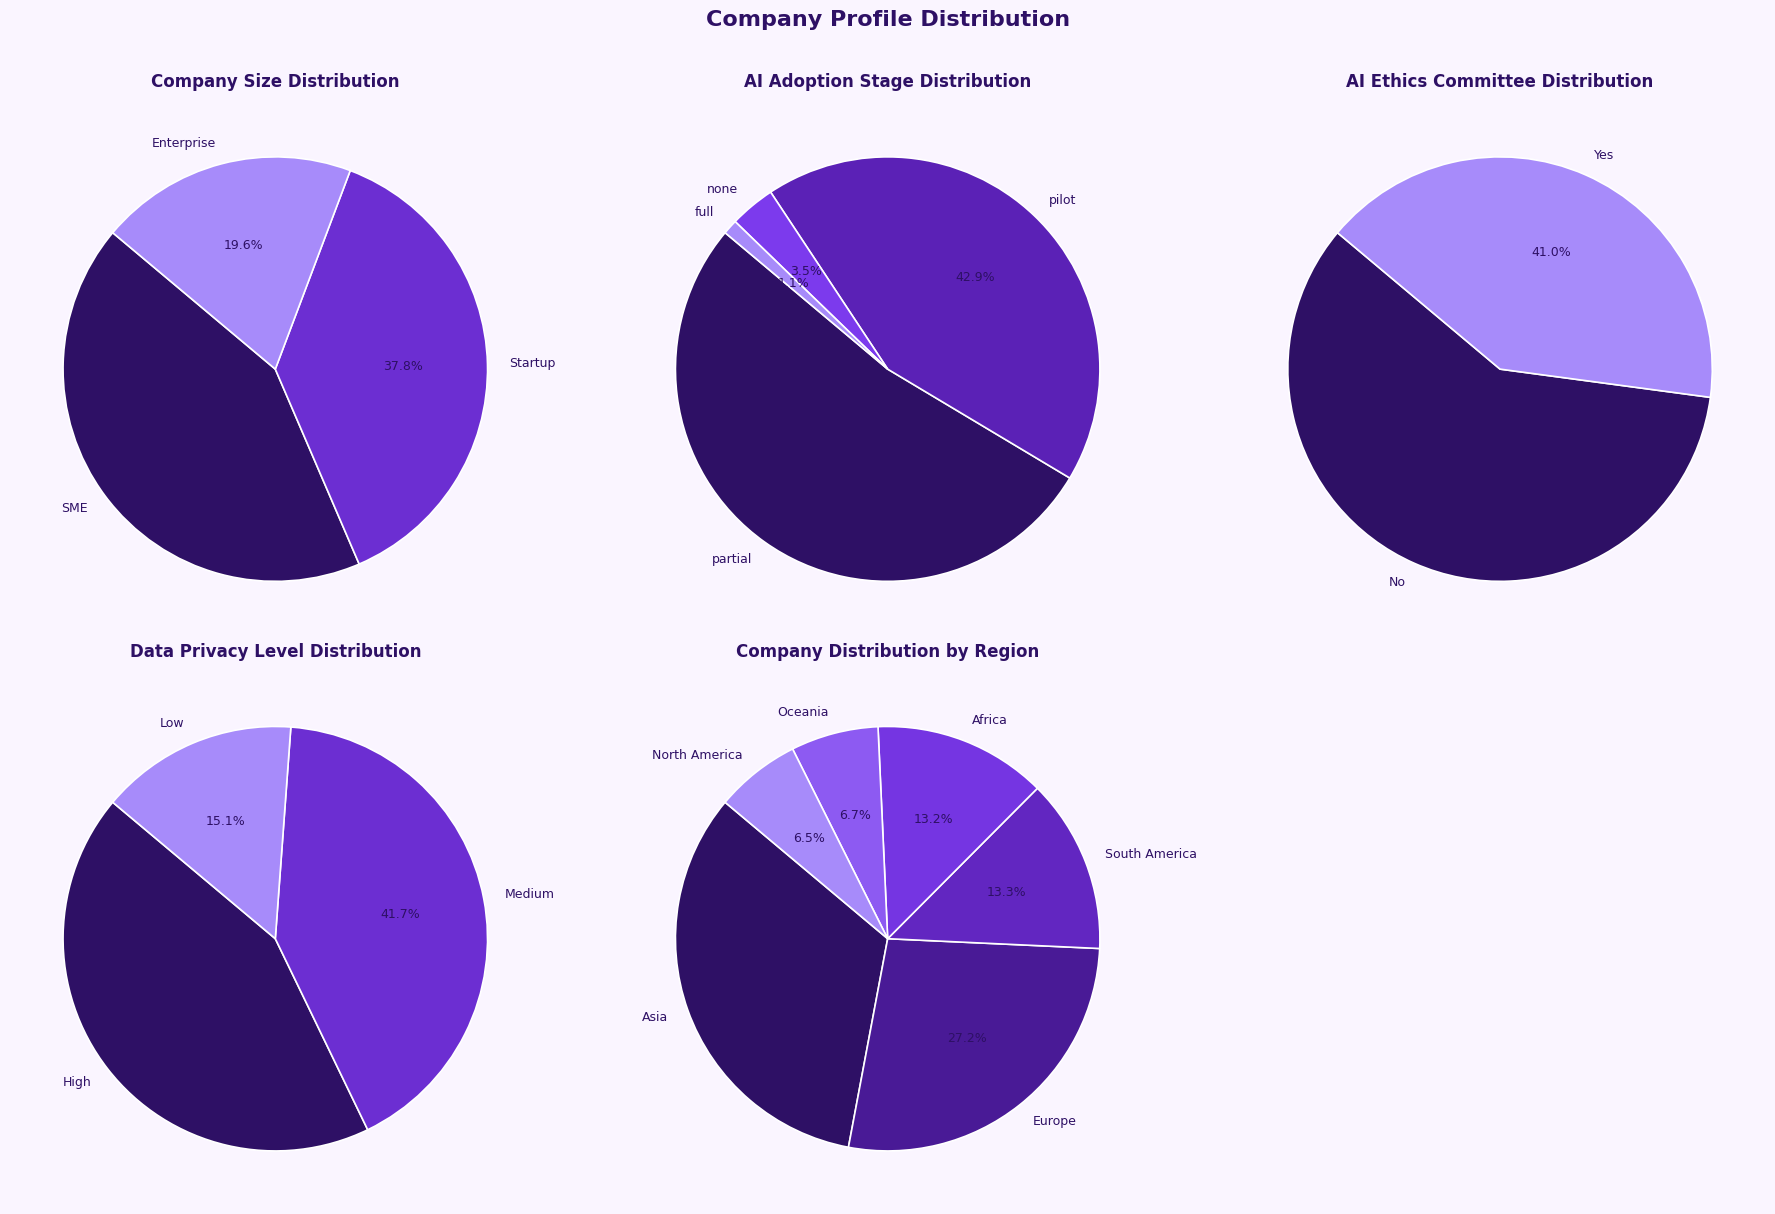

In [ ]:
# ===========================================================================================================================
# PIE CHART DISTRIBUTION - COMPANY SIZE, ADOPTION STAGE, ETHICS COMMITTEE, DATA PRIVACY, REGION
# ===========================================================================================================================

pie_configs = [
    ('company_size',        'Company Size Distribution'),
    ('ai_adoption_stage',   'AI Adoption Stage Distribution'),
    ('ai_ethics_committee', 'AI Ethics Committee Distribution'),
    ('data_privacy_level',  'Data Privacy Level Distribution'),
    ('region',              'Company Distribution by Region'),
]

valid_configs = [(col, title) for col, title in pie_configs if col in df_clean.columns]

n_cols = 3
n_rows = math.ceil(len(valid_configs) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 6))
fig.patch.set_facecolor('#faf5ff')
axes = axes.flatten()

for i, (col, title) in enumerate(valid_configs):
    counts  = df_clean[col].value_counts()
    n_cat   = len(counts)
    colors  = list(CLR_GRADIENT(n_cat))

    axes[i].pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=140,
        wedgeprops=dict(edgecolor='white', linewidth=1.2),
        textprops=dict(color=CLR_DARK, fontsize=9)
    )
    axes[i].set_title(title, fontsize=12, fontweight='bold', color=CLR_DARK, pad=12)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Company Profile Distribution', fontsize=16, fontweight='bold', color=CLR_DARK, y=1.01)
plt.tight_layout()
plt.savefig('eda_pie_charts.png', dpi=150, bbox_inches='tight')
plt.show()

## **Analisis Company Profile Distribution**

Analisis ini bertujuan untuk menggambarkan karakteristik perusahaan yang terlibat dalam adopsi AI berdasarkan ukuran perusahaan, tahap implementasi AI, keberadaan *AI ethics committee*, tingkat privasi data, dan persebaran wilayah. Visualisasi ini membantu memahami profil perusahaan serta kondisi umum implementasi AI pada berbagai sektor dan kawasan.

Berdasarkan diagram distribusi perusahaan di atas, mayoritas perusahaan berasal dari kategori SME dengan persentase sekitar 42,6%, disusul *startup* sebesar 37,8%, sedangkan *enterprise* memiliki jumlah paling sedikit. Dari sisi tahap adopsi AI, sebagian besar perusahaan masih berada pada tahap *partial* dan *pilot*, yang menunjukkan bahwa implementasi AI masih dalam proses pengembangan dan belum sepenuhnya diterapkan secara menyeluruh.

Selain itu, sebanyak 59% perusahaan belum memiliki *AI ethics committee*, sehingga isu etika dan pengawasan AI masih menjadi tantangan dalam implementasi teknologi ini. Pada aspek privasi data, mayoritas perusahaan memiliki tingkat perlindungan data tinggi dan menengah, yang menandakan kesadaran terhadap keamanan data sudah cukup baik. Dilihat dari persebaran wilayah, perusahaan paling banyak berasal dari Asia dan Eropa, sehingga kedua kawasan tersebut dapat dikatakan menjadi pusat perkembangan adopsi AI yang cukup dominan.

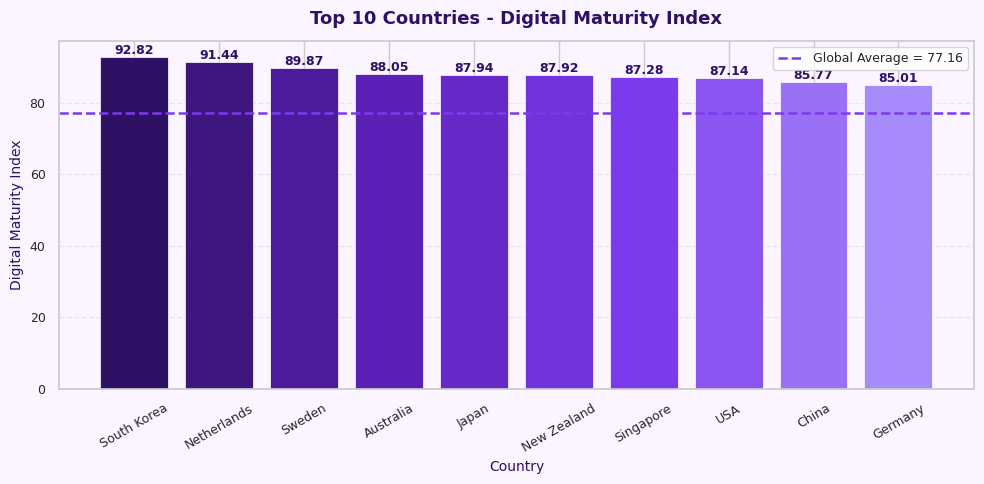

In [ ]:
# ===========================================================================================================================
# TOP 10 COUNTRIES BY DIGITAL MATURITY
# ===========================================================================================================================

top_country = df_country.sort_values('digital_maturity_index', ascending=False).head(10)
global_avg  = df_country['digital_maturity_index'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#faf5ff')
ax.set_facecolor('#faf5ff')

bars = ax.bar(top_country['country'],
              top_country['digital_maturity_index'],
              color=CLR_GRADIENT(10),
              edgecolor='white', lw=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=CLR_DARK)

ax.axhline(global_avg, color=CLR_PRIMARY, ls='--', lw=1.8,
           label=f'Global Average = {global_avg:.2f}')

ax.set_title('Top 10 Countries - Digital Maturity Index',
             fontsize=13, fontweight='bold', color=CLR_DARK, pad=12)
ax.set_xlabel('Country', fontsize=10, color=CLR_DARK)
ax.set_ylabel('Digital Maturity Index', fontsize=10, color=CLR_DARK)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', labelsize=9)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('eda_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()

## **Analisis Digital Maturity Index**

Analisis ini bertujuan untuk membandingkan tingkat kematangan digital (*Digital Maturity Index*) antarnegara serta mengidentifikasi negara dengan kesiapan digital tertinggi. Visualisasi ini membantu memahami sejauh mana kualitas infrastruktur digital, pemanfaatan teknologi, dan kesiapan transformasi digital berkembang pada masing-masing negara.

Berdasarkan grafik *Top 10 Countries - Digital Maturity Index*, Korea Selatan menempati posisi tertinggi dengan nilai indeks sekitar 92,82, diikuti Belanda dan Swedia. Hal ini menunjukkan bahwa negara-negara tersebut memiliki tingkat kesiapan digital, infrastruktur teknologi, serta pemanfaatan teknologi informasi yang sangat baik dibanding negara lain. Selain itu, seluruh negara pada grafik memiliki nilai di atas rata-rata global sebesar 77,16, sehingga dapat dikatakan bahwa negara-negara tersebut termasuk kategori dengan perkembangan digital yang maju.

Di sisi lain, negara seperti Jerman dan China berada pada posisi terbawah dalam daftar *top 10* meskipun nilainya masih tergolong tinggi, yaitu di atas 85. Secara keseluruhan, grafik ini memperlihatkan bahwa negara-negara maju di kawasan Asia, Eropa, dan Amerika memiliki peran penting dalam perkembangan transformasi digital dunia.

In [ ]:
# ===========================================================================================================================
# COUNTRY-LEVEL AI ADOPTION ANALYSIS
# ===========================================================================================================================

import numpy as np
import matplotlib.pyplot as plt

CLR_PRIMARY  = '#6A0DAD'
CLR_GRADIENT = lambda n: plt.cm.Purples(np.linspace(0.35, 0.95, n))

# ===========================================================================================================================
# GROUPBY COUNTRY
# ===========================================================================================================================

country_avg = df_clean.groupby('country').agg(
    adoption      = ('ai_adoption_rate',           'mean'),
    productivity  = ('productivity_change_percent', 'mean'),
    automation    = ('task_automation_rate',        'mean'),
    jobs_displaced= ('jobs_displaced',              'mean'),
    jobs_created  = ('jobs_created',               'mean'),
    companies     = ('country',                    'count')
).reset_index()

# ===========================================================================================================================
# INTERACTIVE MAP (PLOTLY)
# ===========================================================================================================================

PLOTLY = True

if PLOTLY:
    import plotly.express as px

    fig = px.choropleth(
        country_avg,
        locations         = 'country',
        locationmode      = 'country names',
        color             = 'adoption',
        hover_name        = 'country',
        hover_data        = {
            'adoption'      : ':.1f',
            'productivity'  : ':.1f',
            'automation'    : ':.1f',
            'jobs_displaced': ':.1f',
            'jobs_created'  : ':.1f',
            'companies'     : ':,'
        },
        color_continuous_scale = 'Purples',
        title                  = '🌍 Global AI Adoption Rate by Country (2023-2026 Average)',
        labels                 = {'adoption': 'Avg Adoption %'}
    )

    fig.update_layout(
        title_font_size  = 18,
        title_font_color = '#4a235a',
        height           = 520,
        geo              = dict(
            showframe      = False,
            showcoastlines = True,
            projection_type= 'natural earth'
        ),
        coloraxis_colorbar = dict(
            title      = 'AI Adoption %',
            ticksuffix = '%'
        )
    )

    fig.show()

# ===========================================================================================================================
# FALLBACK BAR CHART (IF PLOTLY NOT AVAILABLE)
# ===========================================================================================================================

else:
    top20 = country_avg.sort_values('adoption', ascending=True).tail(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('#faf5ff')
    ax.set_facecolor('#faf5ff')

    ax.barh(
        top20['country'],
        top20['adoption'],
        color     = CLR_GRADIENT(len(top20)),
        edgecolor = 'white',
        linewidth = 0.5
    )

    for i, v in enumerate(top20['adoption']):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9, color='#4a235a')

    ax.set_title('🌍 Top 20 Countries by AI Adoption Rate',
                 fontsize=14, fontweight='bold', color='#4a235a', pad=12)
    ax.set_xlabel('Average AI Adoption Rate (%)', fontsize=10)
    ax.set_ylabel('Country', fontsize=10)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

## **Analisis Global AI Adoption Rate by Country**

Analisis ini bertujuan untuk melihat persebaran tingkat adopsi AI antarnegara serta mengidentifikasi wilayah dengan penggunaan AI yang relatif tinggi maupun rendah selama periode 2023–2026. Visualisasi peta membantu memahami bagaimana perkembangan AI tersebar secara global dan menunjukkan perbedaan kesiapan teknologi antarnegara.

Berdasarkan peta *Global AI Adoption Rate by Country (2023-2026 Average)*, terlihat bahwa tingkat adopsi AI di beberapa negara maju cenderung lebih tinggi dibanding negara berkembang. Amerika Serikat dan Australia memiliki persentase adopsi AI tertinggi dengan warna paling gelap, yang menunjukkan bahwa kedua negara tersebut sangat aktif dalam penerapan teknologi AI di berbagai sektor industri dan layanan.

Selain itu, negara-negara di Eropa seperti Inggris, Jerman, dan Prancis juga menunjukkan tingkat adopsi AI yang cukup tinggi. Di kawasan Asia, Jepang, Korea Selatan, India, dan beberapa negara Asia Tenggara mulai mengalami peningkatan penggunaan AI secara signifikan. Secara keseluruhan, visualisasi ini menunjukkan bahwa transformasi digital berbasis AI semakin berkembang secara global dan menjadi salah satu faktor penting dalam meningkatkan daya saing teknologi suatu negara.

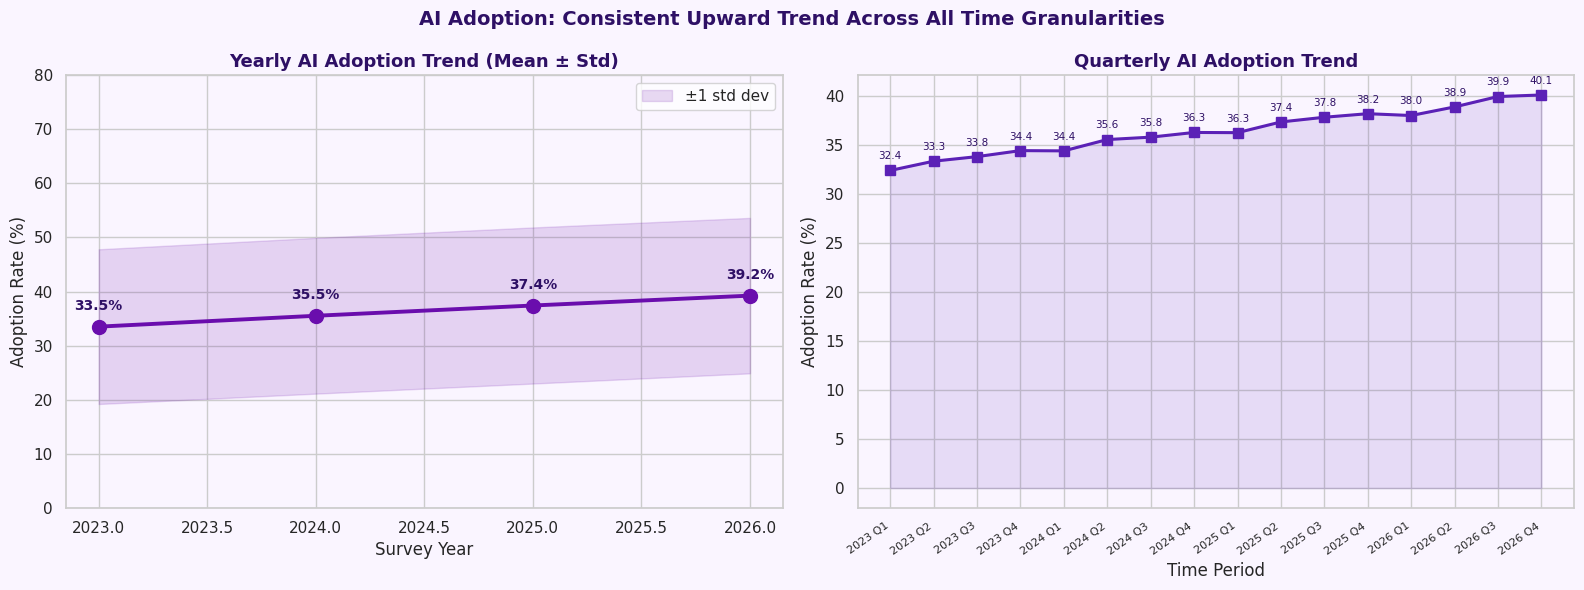

Total growth 2023→2026 : +5.74 percentage points
Average annual growth  : +1.91 pp/year
Growth rate (CAGR-like): 5.41%/year


In [ ]:
# ===========================================================================================================================
# AI ADOPTION TREND - YEARLY & QUARTERLY
# ===========================================================================================================================

yearly = df_clean.groupby('survey_year')['ai_adoption_rate'].agg(['mean', 'std', 'median']).reset_index()

if 'quarter' in df_clean.columns:
    df_clean['time_period'] = (
        df_clean['survey_year'] +
        df_clean['quarter'].str.extract(r'Q(\d)')[0].astype(int)
        .map({1: 0.0, 2: 0.25, 3: 0.5, 4: 0.75})
    )
    quarterly = (
        df_clean.groupby(['survey_year', 'quarter', 'time_period'])['ai_adoption_rate']
        .mean()
        .reset_index()
        .sort_values('time_period')
    )

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#faf5ff')

# -- Plot 1: Yearly trend with ±1 std confidence band --
axes[0].plot(yearly['survey_year'], yearly['mean'],
             marker='o', linewidth=2.8, color=CLR_PRIMARY, markersize=10, zorder=3)
axes[0].fill_between(yearly['survey_year'],
                     yearly['mean'] - yearly['std'],
                     yearly['mean'] + yearly['std'],
                     alpha=0.15, color=CLR_PRIMARY, label='±1 std dev')
for _, row in yearly.iterrows():
    axes[0].annotate(f"{row['mean']:.1f}%",
                     (row['survey_year'], row['mean']),
                     textcoords='offset points', xytext=(0, 12),
                     ha='center', fontweight='bold', color=CLR_DARK, fontsize=10)
axes[0].set_title('Yearly AI Adoption Trend (Mean ± Std)',
                  fontsize=13, fontweight='bold', color=CLR_DARK)
axes[0].set_xlabel('Survey Year')
axes[0].set_ylabel('Adoption Rate (%)')
axes[0].set_ylim(0, 80)
axes[0].legend()
axes[0].set_facecolor('#faf5ff')

# -- Plot 2: Quarterly trend --
if 'quarter' in df_clean.columns:
    axes[1].plot(quarterly['time_period'], quarterly['ai_adoption_rate'],
                 marker='s', linewidth=2.2, color=CLR_SECONDARY, markersize=7)
    axes[1].fill_between(quarterly['time_period'], quarterly['ai_adoption_rate'],
                         alpha=0.12, color=CLR_SECONDARY)
    for _, row in quarterly.iterrows():
        axes[1].annotate(f"{row['ai_adoption_rate']:.1f}",
                         (row['time_period'], row['ai_adoption_rate']),
                         textcoords='offset points', xytext=(0, 8),
                         ha='center', fontsize=7.5, color=CLR_DARK)
    axes[1].set_title('Quarterly AI Adoption Trend',
                      fontsize=13, fontweight='bold', color=CLR_DARK)
    axes[1].set_xlabel('Time Period')
    axes[1].set_ylabel('Adoption Rate (%)')
    axes[1].set_xticks(quarterly['time_period'])
    axes[1].set_xticklabels(
        [f"{int(t)} Q{int((t % 1) * 4) + 1}" for t in quarterly['time_period']],
        rotation=35, ha='right', fontsize=8
    )
    axes[1].set_facecolor('#faf5ff')

plt.suptitle('AI Adoption: Consistent Upward Trend Across All Time Granularities',
             fontsize=14, fontweight='bold', color=CLR_DARK)
plt.tight_layout()
plt.savefig('trend_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# ===========================================================================================================================
# SUMMARY METRICS
# ===========================================================================================================================

total_growth = yearly['mean'].iloc[-1] - yearly['mean'].iloc[0]
avg_annual   = total_growth / (len(yearly) - 1)
cagr_like    = ((yearly['mean'].iloc[-1] / yearly['mean'].iloc[0]) ** (1/3) - 1) * 100

print(f"Total growth 2023→2026 : +{total_growth:.2f} percentage points")
print(f"Average annual growth  : +{avg_annual:.2f} pp/year")
print(f"Growth rate (CAGR-like): {cagr_like:.2f}%/year")

## **Analisis AI Adoption Trend**

Analisis ini bertujuan untuk mengamati perkembangan tingkat adopsi AI dari waktu ke waktu serta mengidentifikasi apakah terdapat tren peningkatan atau penurunan penggunaan AI pada periode tertentu. Visualisasi ini membantu memahami dinamika pertumbuhan adopsi AI dan memberikan gambaran mengenai arah perkembangan teknologi AI di masa mendatang.

Berdasarkan grafik *AI Adoption Trend*, terlihat bahwa tingkat adopsi AI mengalami peningkatan yang konsisten dari tahun 2023 hingga 2026. Rata-rata adopsi AI meningkat dari sekitar 33,5% pada tahun 2023 menjadi 39,2% pada tahun 2026. Hal ini menunjukkan bahwa penggunaan teknologi AI semakin diterima dan dimanfaatkan oleh berbagai sektor untuk mendukung efisiensi serta inovasi bisnis.

Pada grafik kuartalan, kenaikan adopsi AI juga terlihat cukup stabil di setiap periode, meskipun terdapat beberapa fase dengan peningkatan yang lebih lambat. Nilai adopsi tertinggi terjadi pada 2026 Q4 dengan persentase sekitar 40,1%. Secara keseluruhan, visualisasi ini menunjukkan bahwa perkembangan AI terus mengalami tren positif dan diperkirakan akan semakin berkembang di masa mendatang seiring meningkatnya kebutuhan transformasi digital global.

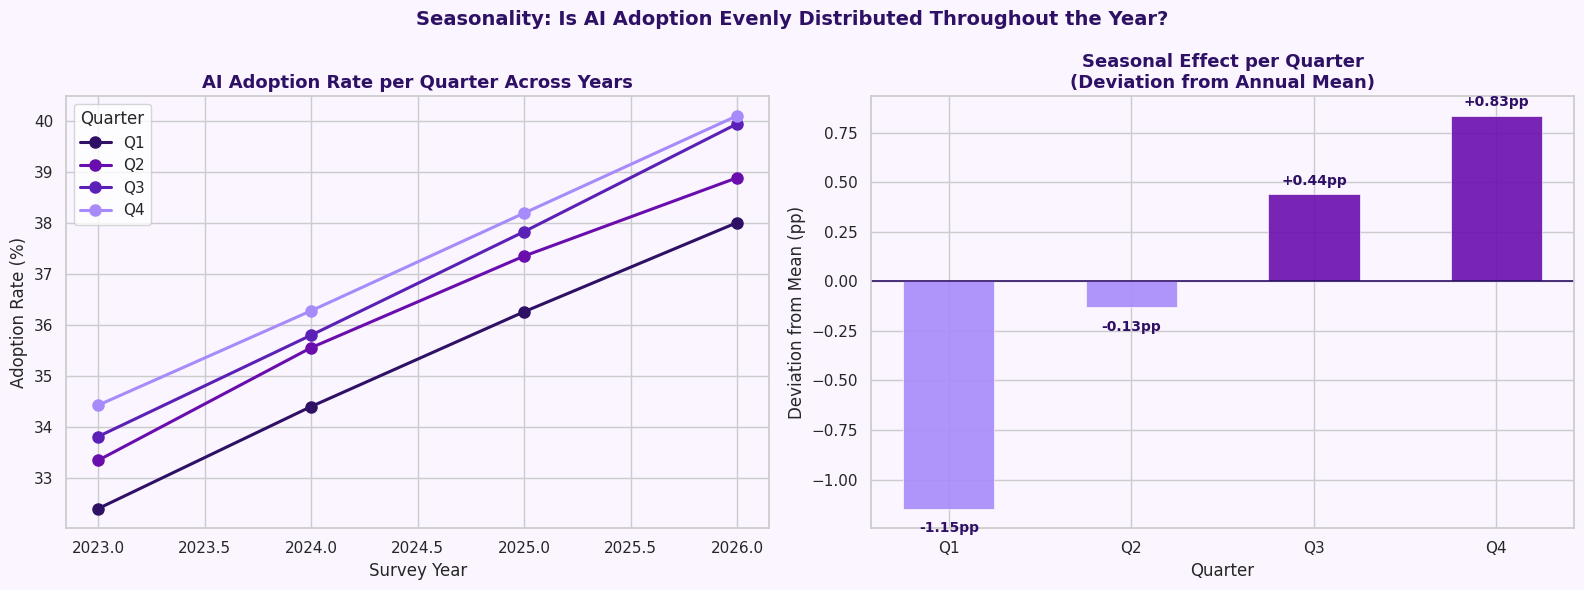

Seasonal effect per quarter:
  Q1: -1.146pp below annual mean
  Q2: -0.128pp below annual mean
  Q3: +0.438pp above annual mean
  Q4: +0.835pp above annual mean


In [ ]:
# ===========================================================================================================================
# SEASONAL ANALYSIS - QUARTERLY AI ADOPTION PATTERNS
# ===========================================================================================================================

seasonal       = df_clean.groupby(['quarter', 'survey_year'])['ai_adoption_rate'].mean().reset_index()
seasonal_pivot = seasonal.pivot(index='survey_year', columns='quarter', values='ai_adoption_rate')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#faf5ff')

# -- Plot 1: AI adoption trend per quarter across years --
quarter_colors = {
    'Q1': CLR_DARK,
    'Q2': CLR_PRIMARY,
    'Q3': CLR_SECONDARY,
    'Q4': CLR_SOFT
}

for q, color in quarter_colors.items():
    if q in seasonal_pivot.columns:
        axes[0].plot(seasonal_pivot.index, seasonal_pivot[q],
                     marker='o', linewidth=2.2, color=color, label=q, markersize=8)

axes[0].set_title('AI Adoption Rate per Quarter Across Years',
                  fontsize=13, fontweight='bold', color=CLR_DARK)
axes[0].set_xlabel('Survey Year')
axes[0].set_ylabel('Adoption Rate (%)')
axes[0].legend(title='Quarter')
axes[0].set_facecolor('#faf5ff')

# -- Plot 2: Seasonal effect (deviation from annual mean) --
q_avg     = df_clean.groupby('quarter')['ai_adoption_rate'].mean().reindex(['Q1', 'Q2', 'Q3', 'Q4'])
q_overall = df_clean['ai_adoption_rate'].mean()
q_diff    = q_avg - q_overall

bar_colors = [CLR_PRIMARY if v >= 0 else CLR_SOFT for v in q_diff.values]

axes[1].bar(q_diff.index, q_diff.values,
            color=bar_colors, edgecolor='white', lw=0.5, alpha=0.9, width=0.5)
axes[1].axhline(0, color=CLR_DARK, linewidth=1.2)

for i, (q, val) in enumerate(q_diff.items()):
    axes[1].text(i, val + (0.05 if val >= 0 else -0.12),
                 f'{val:+.2f}pp', ha='center',
                 fontweight='bold', fontsize=10, color=CLR_DARK)

axes[1].set_title('Seasonal Effect per Quarter\n(Deviation from Annual Mean)',
                  fontsize=13, fontweight='bold', color=CLR_DARK)
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Deviation from Mean (pp)')
axes[1].set_facecolor('#faf5ff')

plt.suptitle('Seasonality: Is AI Adoption Evenly Distributed Throughout the Year?',
             fontsize=14, fontweight='bold', color=CLR_DARK)
plt.tight_layout()
plt.savefig('seasonality_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()

# ===========================================================================================================================
# SUMMARY METRICS
# ===========================================================================================================================

print("Seasonal effect per quarter:")
for q, val in q_diff.items():
    direction = "above" if val >= 0 else "below"
    print(f"  {q}: {val:+.3f}pp {direction} annual mean")

## **Analisis Seasonality AI Adoption**

Analisis ini bertujuan untuk melihat apakah tingkat adopsi AI terdistribusi secara merata sepanjang tahun atau menunjukkan pola musiman (*seasonality*) pada periode tertentu. Dengan analisis ini, dapat diketahui kuartal yang memiliki kecenderungan tingkat adopsi AI lebih tinggi atau lebih rendah dibandingkan rata-rata tahunan.

Berdasarkan grafik, tingkat adopsi AI menunjukkan tren peningkatan yang konsisten dari tahun 2023 hingga 2026 pada seluruh kuartal. Q4 menjadi periode dengan tingkat adopsi tertinggi, sedangkan Q1 cenderung memiliki nilai paling rendah. Hal ini menunjukkan bahwa adopsi AI tidak terdistribusi secara merata sepanjang tahun dan terdapat pola musiman (*seasonality*).

Grafik efek musiman juga memperlihatkan bahwa Q1 dan Q2 memiliki deviasi negatif terhadap rata-rata tahunan, masing-masing sekitar -1,15 pp dan -0,13 pp. Sebaliknya, Q3 dan terutama Q4 menunjukkan deviasi positif, dengan Q4 mencapai +0,83 pp. Pola ini mengindikasikan bahwa adopsi AI cenderung meningkat pada paruh akhir tahun, kemungkinan dipengaruhi oleh evaluasi kinerja, penyesuaian strategi bisnis, atau realisasi anggaran perusahaan menjelang akhir tahun.

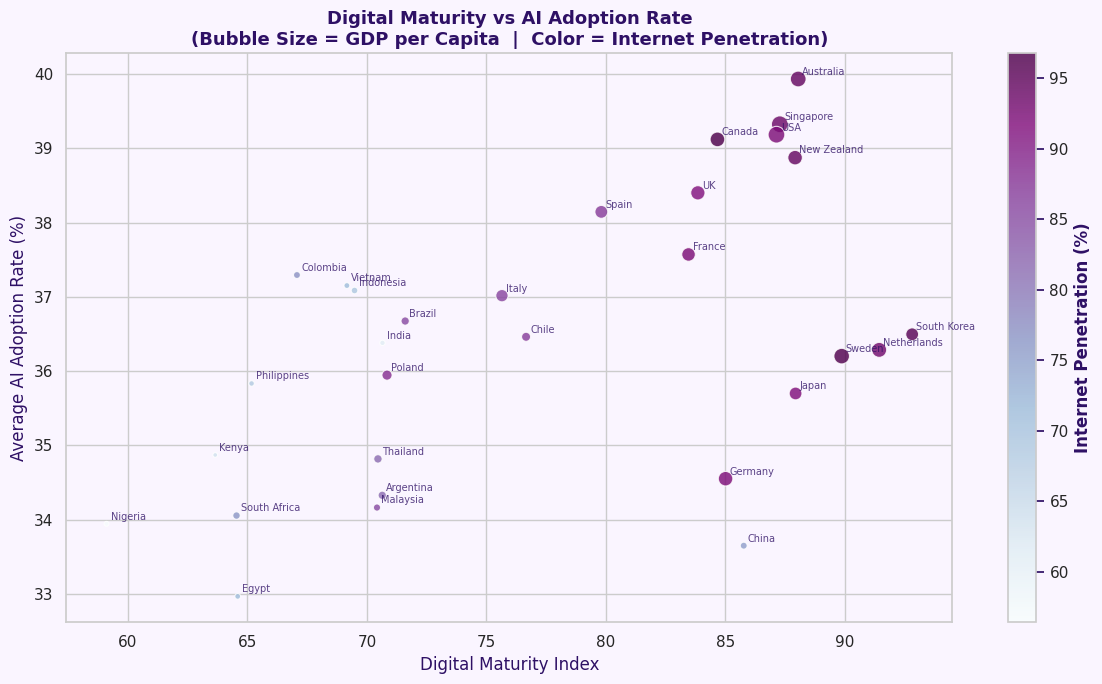


Correlation with AI Adoption Rate:
  gdp_per_capita                : +0.671  [Strong]  █████████████
  internet_penetration          : +0.522  [Moderate]  ██████████
  digital_maturity_index        : +0.521  [Moderate]  ██████████


In [ ]:
# ===========================================================================================================================
# BUBBLE CHART - DIGITAL MATURITY VS AI ADOPTION RATE
# ===========================================================================================================================

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#faf5ff')
ax.set_facecolor('#faf5ff')

# -- Merge company data with country index --
merged = (
    df_clean.groupby('country')['ai_adoption_rate']
            .mean()
            .reset_index()
            .merge(df_country[['country', 'digital_maturity_index',
                                'gdp_per_capita', 'internet_penetration']],
                   on='country')
)

# -- Bubble chart --
sc = ax.scatter(
    merged['digital_maturity_index'],
    merged['ai_adoption_rate'],
    s          = merged['gdp_per_capita'] / 500,
    c          = merged['internet_penetration'],
    cmap       = 'BuPu',
    alpha      = 0.82,
    edgecolors = 'white',
    linewidth  = 0.8
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Internet Penetration (%)', color=CLR_DARK, fontweight='bold')
cbar.ax.yaxis.set_tick_params(color=CLR_DARK)

# -- Country name annotations --
for _, row in merged.iterrows():
    ax.annotate(
        row['country'],
        (row['digital_maturity_index'], row['ai_adoption_rate']),
        fontsize   = 7,
        alpha      = 0.78,
        color      = CLR_DARK,
        xytext     = (3, 3),
        textcoords = 'offset points'
    )

ax.set_xlabel('Digital Maturity Index', color=CLR_DARK)
ax.set_ylabel('Average AI Adoption Rate (%)', color=CLR_DARK)
ax.set_title(
    'Digital Maturity vs AI Adoption Rate\n'
    '(Bubble Size = GDP per Capita  |  Color = Internet Penetration)',
    fontsize=13, fontweight='bold', color=CLR_DARK
)

plt.tight_layout()
plt.savefig('bubble_macro_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# ===========================================================================================================================
# CORRELATION WITH AI ADOPTION RATE
# ===========================================================================================================================

corr = merged[['digital_maturity_index', 'gdp_per_capita',
               'internet_penetration', 'ai_adoption_rate']].corr()

print("\nCorrelation with AI Adoption Rate:")
print("=" * 45)

corr_result = (
    corr['ai_adoption_rate']
    .drop('ai_adoption_rate')
    .sort_values(ascending=False)
)

for var, val in corr_result.items():
    strength = ('Strong' if abs(val) >= 0.6
                else 'Moderate' if abs(val) >= 0.3
                else 'Weak')
    bar = '█' * max(1, int(abs(val) * 20))
    print(f"  {var:30s}: {val:+.3f}  [{strength}]  {bar}")

print("=" * 45)

## **Analisis Digital Maturity dan AI Adoption Rate**

Analisis ini bertujuan untuk mengetahui hubungan antara tingkat kematangan digital (*Digital Maturity Index*) dengan tingkat adopsi AI di berbagai negara. Selain itu, visualisasi ini juga digunakan untuk melihat pengaruh faktor pendukung lain, seperti penetrasi internet dan GDP per kapita, terhadap implementasi AI. Dengan demikian, analisis ini membantu memahami apakah kesiapan digital suatu negara berkaitan dengan keberhasilan adopsi teknologi AI.

Berdasarkan grafik, terlihat adanya kecenderungan hubungan positif antara *Digital Maturity Index* dan tingkat adopsi AI. Negara dengan tingkat kematangan digital yang tinggi umumnya memiliki rata-rata adopsi AI yang lebih besar, seperti Australia, Singapura, dan Amerika Serikat yang berada pada kelompok kanan atas grafik. Hal ini menunjukkan bahwa infrastruktur digital dan kesiapan teknologi berperan penting dalam mendukung implementasi AI.

Selain itu, **gradasi warna pada titik data** yang merepresentasikan penetrasi internet juga memperlihatkan pola serupa, di mana negara dengan penetrasi internet tinggi cenderung memiliki adopsi AI yang lebih baik. Ukuran gelembung yang menggambarkan GDP per kapita menunjukkan bahwa negara dengan pendapatan per kapita lebih tinggi umumnya memiliki kapasitas investasi teknologi yang lebih besar. Namun, terdapat beberapa pengecualian seperti China dan Jepang yang menunjukkan bahwa tingkat adopsi AI tidak hanya dipengaruhi oleh kematangan digital, tetapi juga faktor kebijakan, strategi industri, dan kesiapan sumber daya manusia.

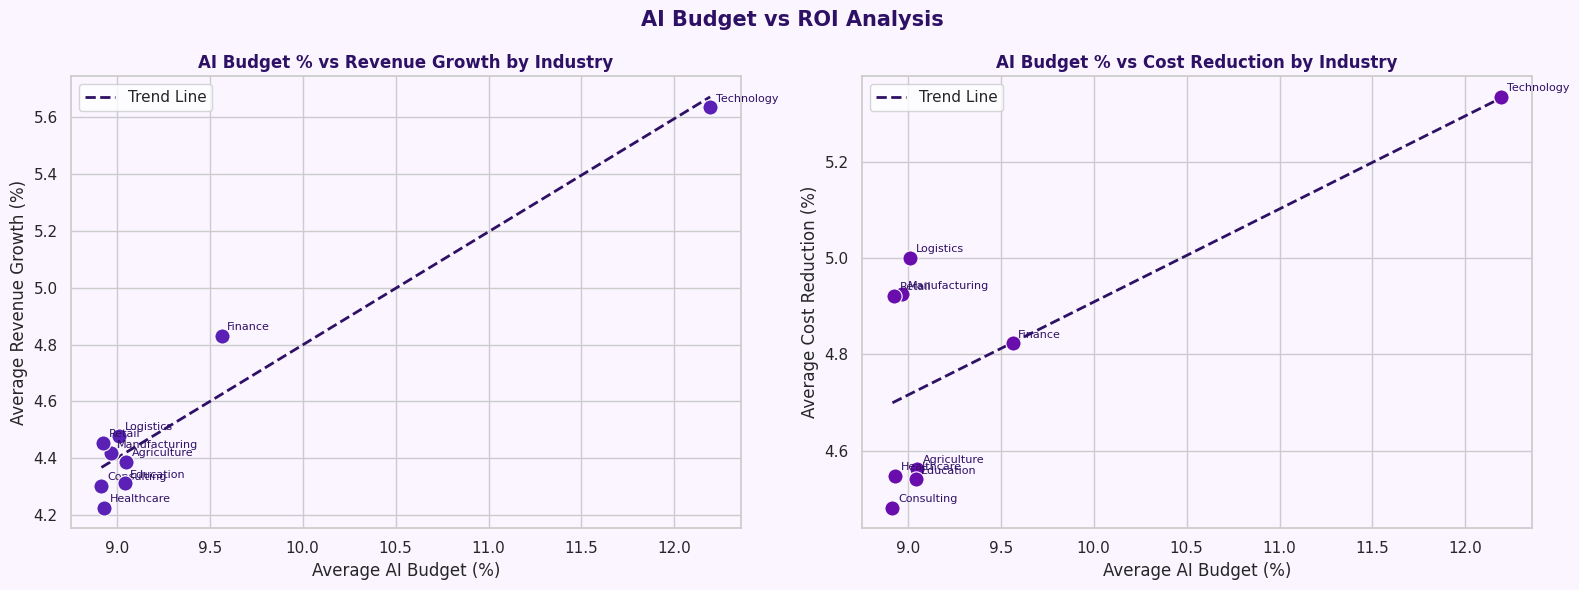

In [ ]:
# ===========================================================================================================================
# AI BUDGET VS ROI - REVENUE GROWTH & COST REDUCTION PER INDUSTRY
# ===========================================================================================================================

budget_roi = df_clean.groupby('industry').agg(
    avg_budget        = ('ai_budget_percentage',  'mean'),
    avg_revenue_growth= ('revenue_growth_percent', 'mean'),
    avg_cost_reduction= ('cost_reduction_percent', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#faf5ff')

# -- Plot 1: Budget vs Revenue Growth --
for i, row in budget_roi.iterrows():
    axes[0].scatter(row['avg_budget'], row['avg_revenue_growth'],
                    s=120, color=CLR_SECONDARY, edgecolors='white', linewidth=0.8, zorder=3)
    axes[0].annotate(row['industry'],
                     (row['avg_budget'], row['avg_revenue_growth']),
                     fontsize=8, color=CLR_DARK, xytext=(4, 4), textcoords='offset points')

coef = np.polyfit(budget_roi['avg_budget'], budget_roi['avg_revenue_growth'], 1)
x_range = np.linspace(budget_roi['avg_budget'].min(), budget_roi['avg_budget'].max(), 100)
axes[0].plot(x_range, np.poly1d(coef)(x_range), color=CLR_DARK, lw=2, ls='--', label='Trend Line')
axes[0].set_title('AI Budget % vs Revenue Growth by Industry',
                  fontsize=12, fontweight='bold', color=CLR_DARK)
axes[0].set_xlabel('Average AI Budget (%)')
axes[0].set_ylabel('Average Revenue Growth (%)')
axes[0].legend()
axes[0].set_facecolor('#faf5ff')

# -- Plot 2: Budget vs Cost Reduction --
for i, row in budget_roi.iterrows():
    axes[1].scatter(row['avg_budget'], row['avg_cost_reduction'],
                    s=120, color=CLR_PRIMARY, edgecolors='white', linewidth=0.8, zorder=3)
    axes[1].annotate(row['industry'],
                     (row['avg_budget'], row['avg_cost_reduction']),
                     fontsize=8, color=CLR_DARK, xytext=(4, 4), textcoords='offset points')

coef2 = np.polyfit(budget_roi['avg_budget'], budget_roi['avg_cost_reduction'], 1)
axes[1].plot(x_range, np.poly1d(coef2)(x_range), color=CLR_DARK, lw=2, ls='--', label='Trend Line')
axes[1].set_title('AI Budget % vs Cost Reduction by Industry',
                  fontsize=12, fontweight='bold', color=CLR_DARK)
axes[1].set_xlabel('Average AI Budget (%)')
axes[1].set_ylabel('Average Cost Reduction (%)')
axes[1].legend()
axes[1].set_facecolor('#faf5ff')

plt.suptitle('AI Budget vs ROI Analysis', fontsize=15, fontweight='bold', color=CLR_DARK)
plt.tight_layout()
plt.savefig('ai_budget_roi.png', dpi=150, bbox_inches='tight')
plt.show()

## **Analisis AI Budget vs ROI**

AI Budget vs ROI menunjukkan hubungan antara `ai_budget_percentage` dengan `revenue_growth_percent` dan `cost_reduction_percent` pada setiap industri untuk melihat apakah investasi AI benar-benar memberikan manfaat bisnis (*worth it*). Analisis ini membantu mengevaluasi efektivitas alokasi anggaran AI terhadap peningkatan pendapatan dan efisiensi operasional perusahaan.

Grafik pertama digunakan untuk menganalisis apakah industri yang mengalokasikan anggaran AI lebih besar cenderung mengalami peningkatan pendapatan yang lebih tinggi. Sementara itu, grafik kedua bertujuan melihat apakah investasi AI juga berkontribusi terhadap efisiensi biaya perusahaan. Adanya *trend line* membantu menunjukkan arah hubungan antar variabel, apakah positif, negatif, atau lemah.

Secara umum, analisis ini berguna untuk mengevaluasi efektivitas investasi AI (*Return on Investment/ROI*) di berbagai sektor industri serta membantu perusahaan memahami apakah peningkatan anggaran AI sejalan dengan peningkatan performa bisnis dan efisiensi operasional.

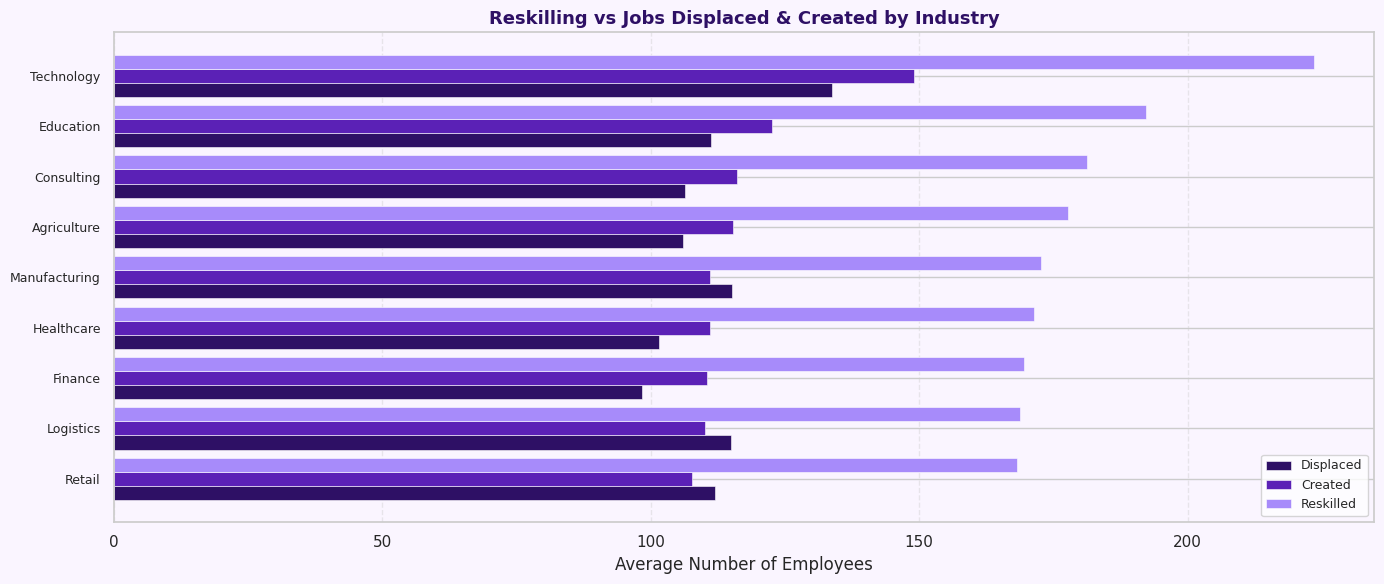

In [ ]:
# ===========================================================================================================================
# RESKILLING ANALYSIS - RESKILLED EMPLOYEES VS JOBS DISPLACED & CREATED
# ===========================================================================================================================

reskill = df_clean.groupby('industry').agg(
    avg_reskilled     = ('reskilled_employees', 'mean'),
    avg_displaced     = ('jobs_displaced',      'mean'),
    avg_created       = ('jobs_created',        'mean')
).reset_index().sort_values('avg_reskilled', ascending=True)

x_pos = np.arange(len(reskill))
bar_w = 0.28

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#faf5ff')
ax.set_facecolor('#faf5ff')

ax.barh(x_pos - bar_w, reskill['avg_displaced'], bar_w,
        label='Displaced', color=CLR_DARK,      edgecolor='white', lw=0.4)
ax.barh(x_pos,          reskill['avg_created'],  bar_w,
        label='Created',   color=CLR_SECONDARY,  edgecolor='white', lw=0.4)
ax.barh(x_pos + bar_w,  reskill['avg_reskilled'],bar_w,
        label='Reskilled', color=CLR_SOFT,       edgecolor='white', lw=0.4)

ax.set_yticks(x_pos)
ax.set_yticklabels(reskill['industry'], fontsize=9)
ax.set_xlabel('Average Number of Employees')
ax.set_title('Reskilling vs Jobs Displaced & Created by Industry',
             fontsize=13, fontweight='bold', color=CLR_DARK)
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('reskilling_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## **Analisis Reskilling vs Jobs Displaced & Created by Industry**

Reskilling Analysis menunjukkan perbandingan antara `reskilled_employees`, `jobs_displaced`, dan `jobs_created` pada setiap industri untuk melihat seberapa siap perusahaan menghadapi perubahan tenaga kerja akibat implementasi AI. Analisis ini membantu memahami bagaimana masing-masing sektor beradaptasi melalui penciptaan pekerjaan baru dan pelatihan ulang karyawan.

Berdasarkan grafik, sektor *Technology* memiliki jumlah pekerjaan baru (*created*) dan karyawan yang menjalani *reskilling* paling tinggi dibanding industri lainnya. Meskipun jumlah pekerjaan yang tergantikan (*displaced*) juga cukup besar, sektor ini tetap menunjukkan penciptaan peluang kerja baru yang lebih tinggi. Hal ini mengindikasikan bahwa perkembangan AI di sektor teknologi mendorong transformasi tenaga kerja sekaligus meningkatkan kebutuhan keterampilan baru.

Selain itu, industri seperti *Education*, *Consulting*, dan *Agriculture* juga menunjukkan jumlah *reskilling* yang relatif tinggi dibanding jumlah pekerjaan yang tergantikan. Kondisi ini menunjukkan adanya upaya adaptasi melalui pelatihan ulang karyawan agar tetap relevan dengan perubahan teknologi. Sementara itu, pada sektor seperti *Retail*, *Logistics*, dan *Manufacturing*, jumlah pekerjaan yang tergantikan cenderung mendekati atau sedikit lebih tinggi dibanding pekerjaan baru yang tercipta, sehingga tantangan transisi tenaga kerja masih cukup besar.

Secara keseluruhan, visualisasi ini menunjukkan bahwa implementasi AI tidak hanya berdampak pada pengurangan pekerjaan tertentu, tetapi juga mendorong penciptaan pekerjaan baru serta peningkatan kebutuhan *reskilling* agar tenaga kerja mampu beradaptasi dengan transformasi digital.

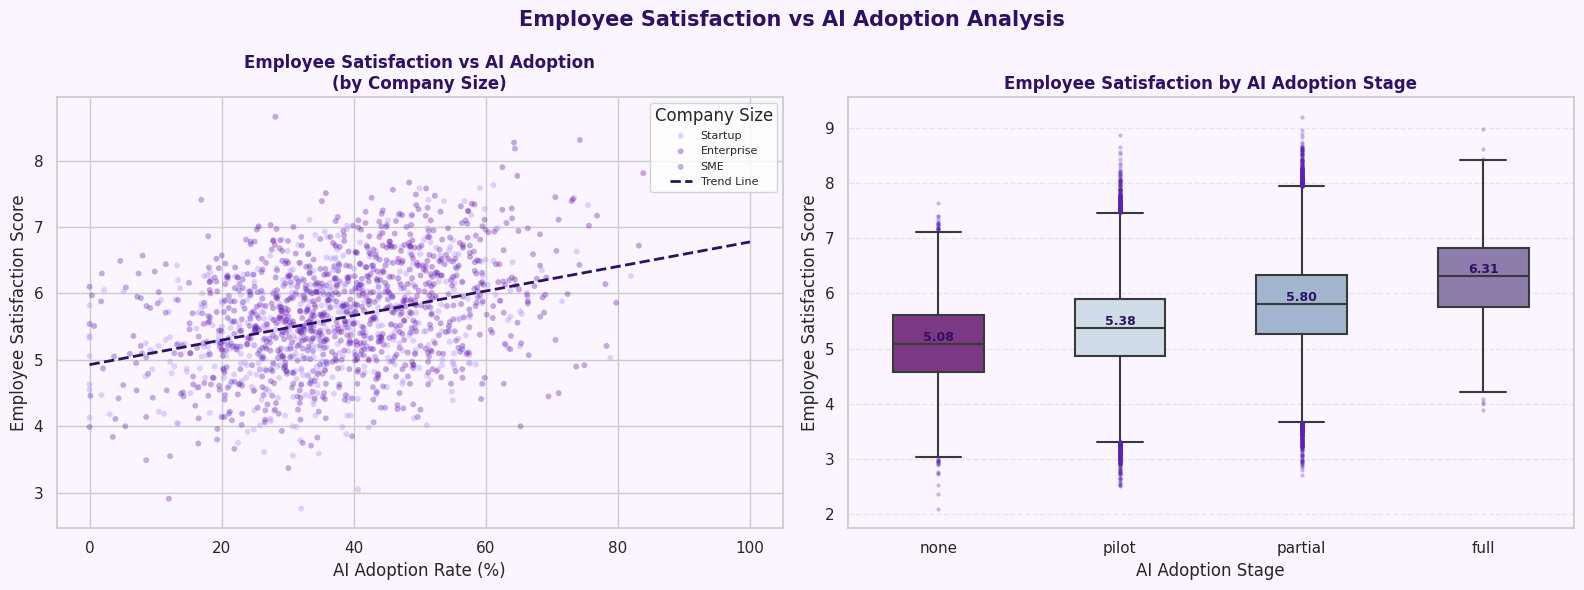

In [ ]:
# ===========================================================================================================================
# EMPLOYEE SATISFACTION VS AI ADOPTION - BY COMPANY SIZE & ADOPTION STAGE
# ===========================================================================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#faf5ff')

# -- Plot 1: Scatter by company_size --
size_groups = df_clean['company_size'].unique()
size_colors = {s: c for s, c in zip(['Startup', 'SME', 'Enterprise'],
                                      [CLR_SOFT, CLR_SECONDARY, CLR_PRIMARY])}
for size in size_groups:
    subset = df_clean[df_clean['company_size'] == size].sample(n=500, random_state=42)
    axes[0].scatter(subset['ai_adoption_rate'], subset['employee_satisfaction_score'],
                    alpha=0.35, s=18, label=size,
                    color=size_colors.get(size, CLR_SECONDARY), edgecolors='none')

coef = np.polyfit(df_clean['ai_adoption_rate'], df_clean['employee_satisfaction_score'], 1)
x_range = np.linspace(df_clean['ai_adoption_rate'].min(), df_clean['ai_adoption_rate'].max(), 100)
axes[0].plot(x_range, np.poly1d(coef)(x_range), color=CLR_DARK, lw=2, ls='--', label='Trend Line')
axes[0].set_title('Employee Satisfaction vs AI Adoption\n(by Company Size)',
                  fontsize=12, fontweight='bold', color=CLR_DARK)
axes[0].set_xlabel('AI Adoption Rate (%)')
axes[0].set_ylabel('Employee Satisfaction Score')
axes[0].legend(title='Company Size', fontsize=8)
axes[0].set_facecolor('#faf5ff')

# -- Plot 2: Boxplot by adoption stage --
stage_order = [s for s in ['none', 'pilot', 'partial', 'full']
               if s in df_clean['ai_adoption_stage'].unique()]
sns.boxplot(data=df_clean, x='ai_adoption_stage', y='employee_satisfaction_score',
            order=stage_order, palette='BuPu', hue='ai_adoption_stage',
            width=0.5, linewidth=1.5, legend=False,
            flierprops=dict(marker='o', markersize=3, alpha=0.3,
                            markerfacecolor=CLR_SECONDARY, markeredgecolor='none'),
            ax=axes[1])
axes[1].set_title('Employee Satisfaction by AI Adoption Stage',
                  fontsize=12, fontweight='bold', color=CLR_DARK)
axes[1].set_xlabel('AI Adoption Stage')
axes[1].set_ylabel('Employee Satisfaction Score')
axes[1].set_facecolor('#faf5ff')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

medians = df_clean.groupby('ai_adoption_stage')['employee_satisfaction_score'].median().reindex(stage_order)
for j, (stage, med) in enumerate(medians.items()):
    axes[1].text(j, med, f'{med:.2f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold', color=CLR_DARK)

plt.suptitle('Employee Satisfaction vs AI Adoption Analysis',
             fontsize=15, fontweight='bold', color=CLR_DARK)
plt.tight_layout()
plt.savefig('employee_satisfaction_ai.png', dpi=150, bbox_inches='tight')
plt.show()

## **Employee Satisfaction vs AI Adoption Analysis**

Employee Satisfaction vs AI Adoption menunjukkan hubungan antara `employee_satisfaction_score` dan `ai_adoption_rate` yang dikelompokkan berdasarkan `company_size` maupun `ai_adoption_stage` untuk melihat apakah implementasi AI memberikan dampak positif atau negatif terhadap kepuasan karyawan.

Berdasarkan *scatter plot*, terlihat adanya hubungan positif antara `AI Adoption Rate` dan `Employee Satisfaction Score`, yang ditunjukkan oleh *trend line* yang terus meningkat. Hal ini menunjukkan bahwa perusahaan dengan tingkat adopsi AI yang lebih tinggi cenderung memiliki tingkat kepuasan karyawan yang lebih baik. Meskipun terdapat variasi data antar perusahaan, pola umum tetap menunjukkan bahwa pemanfaatan AI dapat mendukung lingkungan kerja yang lebih efisien dan produktif.

Selain itu, pada *boxplot* berdasarkan `AI Adoption Stage`, terlihat bahwa tingkat kepuasan karyawan meningkat seiring dengan kematangan implementasi AI. Perusahaan dengan tahap `full` memiliki median kepuasan tertinggi sekitar **6.31**, diikuti `partial` (**5.80**), `pilot` (**5.38**), dan `none` (**5.08**). Hal ini mengindikasikan bahwa implementasi AI yang lebih matang cenderung memberikan pengalaman kerja yang lebih positif bagi karyawan.

Secara keseluruhan, visualisasi ini menunjukkan bahwa adopsi AI tidak hanya berkaitan dengan peningkatan efisiensi perusahaan, tetapi juga berpotensi meningkatkan kepuasan karyawan ketika implementasinya dilakukan secara optimal.

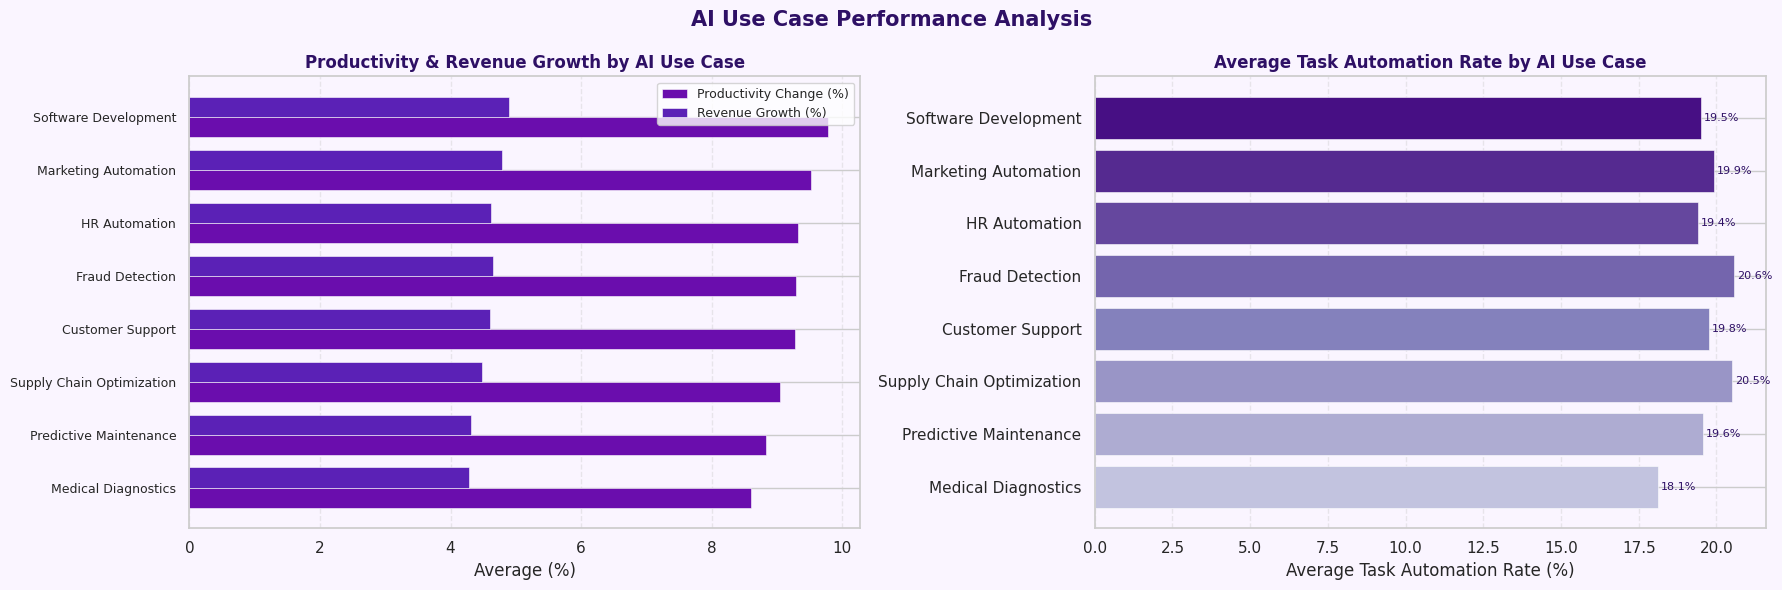

In [ ]:
# ===========================================================================================================================
# AI USE CASE PERFORMANCE - PRODUCTIVITY & REVENUE GROWTH PER USE CASE
# ===========================================================================================================================

usecase_perf = df_clean.groupby('ai_use_case').agg(
    avg_productivity = ('productivity_change_percent', 'mean'),
    avg_revenue      = ('revenue_growth_percent',      'mean'),
    avg_automation   = ('task_automation_rate',        'mean'),
    count            = ('ai_use_case',                 'count')
).reset_index().sort_values('avg_productivity', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#faf5ff')

# -- Plot 1: Productivity & Revenue Growth per Use Case --
x_pos = np.arange(len(usecase_perf))
bar_w = 0.38

axes[0].barh(x_pos - bar_w/2, usecase_perf['avg_productivity'], bar_w,
             label='Productivity Change (%)', color=CLR_PRIMARY,   edgecolor='white', lw=0.4)
axes[0].barh(x_pos + bar_w/2, usecase_perf['avg_revenue'],      bar_w,
             label='Revenue Growth (%)',      color=CLR_SECONDARY, edgecolor='white', lw=0.4)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(usecase_perf['ai_use_case'], fontsize=9)
axes[0].set_title('Productivity & Revenue Growth by AI Use Case',
                  fontsize=12, fontweight='bold', color=CLR_DARK)
axes[0].set_xlabel('Average (%)')
axes[0].legend(fontsize=9)
axes[0].set_facecolor('#faf5ff')
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

# -- Plot 2: Task Automation Rate per Use Case --
axes[1].barh(usecase_perf['ai_use_case'], usecase_perf['avg_automation'],
             color=CLR_GRADIENT(len(usecase_perf)), edgecolor='white', lw=0.4)
for i, val in enumerate(usecase_perf['avg_automation']):
    axes[1].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=8, color=CLR_DARK)
axes[1].set_title('Average Task Automation Rate by AI Use Case',
                  fontsize=12, fontweight='bold', color=CLR_DARK)
axes[1].set_xlabel('Average Task Automation Rate (%)')
axes[1].set_facecolor('#faf5ff')
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('AI Use Case Performance Analysis',
             fontsize=15, fontweight='bold', color=CLR_DARK)
plt.tight_layout()
plt.savefig('usecase_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## **AI Use Case Performance Analysis**

AI Use Case Performance menunjukkan rata-rata `productivity_change_percent` dan `revenue_growth_percent` pada setiap `ai_use_case` untuk melihat penggunaan AI mana yang memberikan dampak bisnis paling besar. Analisis ini membantu membandingkan efektivitas berbagai *AI use case* dalam meningkatkan produktivitas, pertumbuhan pendapatan, serta kontribusinya terhadap efisiensi operasional.

Berdasarkan grafik *Productivity & Revenue Growth by AI Use Case*, hampir seluruh *use case* AI menunjukkan dampak positif terhadap produktivitas dan pertumbuhan pendapatan perusahaan. *Software Development* memiliki peningkatan produktivitas tertinggi, diikuti *Marketing Automation* dan *HR Automation*. Hal ini menunjukkan bahwa penggunaan AI pada aktivitas yang bersifat teknis dan operasional mampu memberikan peningkatan efisiensi kerja yang signifikan.

Selain itu, grafik *Average Task Automation Rate by AI Use Case* memperlihatkan bahwa *Fraud Detection* dan *Supply Chain Optimization* memiliki tingkat otomatisasi tugas tertinggi, masing-masing sekitar **20,6%** dan **20,5%**. Sementara itu, *Medical Diagnostics* memiliki tingkat otomatisasi relatif lebih rendah dibanding *use case* lainnya, meskipun tetap menunjukkan kontribusi positif. Kondisi ini menunjukkan bahwa efektivitas AI dalam otomatisasi dapat berbeda tergantung kompleksitas tugas dan karakteristik bidang penerapannya.

Secara keseluruhan, visualisasi ini menunjukkan bahwa implementasi AI pada berbagai *use case* mampu meningkatkan produktivitas, mendukung pertumbuhan bisnis, dan mempercepat otomatisasi proses kerja, meskipun tingkat dampaknya berbeda pada setiap bidang penggunaan.